# Cloud Server Resource Consumption Prediction

## Problem Statement

Cloud-based applications experience varying workloads throughout the day due to user traffic, API
requests, database queries, and background jobs. Companies need to anticipate server load in
advance to avoid crashes, improve system reliability, and reduce cloud infrastructure costs. In this
project, the objective is to predict server CPU usage percentage using workload, infrastructure, and
operational metrics. Because CPU usage is a continuous value, this is modeled as a regression
problem.

**This notebook contains the project with detailed EDA, Feature Engineering along with Model Building and Evaluation**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("cloud_server_resource_consumption_dataset.csv")

In [3]:
df.head()

,hour_of_day,day_of_week,is_weekend,is_peak_hour,active_users,requests_per_minute,avg_request_size_kb,api_calls_per_minute,db_queries_per_minute,background_jobs_count,...,network_in_mbps,network_out_mbps,disk_read_ops,disk_write_ops,avg_response_time_ms,error_rate_percent,scheduled_job_flag,release_day_flag,cpu_usage_percent,memory_usage_percent
0,6,0,0,0,3040,3528.593163,75.849039,786.849818,406.162846,2,...,36.268301,39.274311,251.509904,392.211125,88.905252,0.618693,0,0,78.908966,83.630484
1,19,1,0,1,4693,3758.887203,95.257798,1056.615844,775.439918,1,...,54.797336,48.349988,1124.970299,343.155215,95.084826,0.533934,0,0,87.715187,65.732609
2,14,5,1,0,1199,1476.103998,66.247144,383.402379,381.597154,3,...,25.665953,23.270123,411.107454,170.836419,57.639430,2.095670,0,0,42.231409,55.649199
3,10,6,1,0,112,167.792816,73.781887,33.884015,28.714088,3,...,1.579843,1.677699,42.820615,18.561441,70.405772,0.792096,0,0,14.467778,43.019040
4,7,1,0,0,4989,5010.979711,6.535530,2083.248968,751.336847,1,...,34.891989,35.135482,665.132626,593.126019,113.564119,1.790406,0,0,96.595032,54.872855


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour_of_day             10000 non-null  int64  
 1   day_of_week             10000 non-null  int64  
 2   is_weekend              10000 non-null  int64  
 3   is_peak_hour            10000 non-null  int64  
 4   active_users            10000 non-null  int64  
 5   requests_per_minute     10000 non-null  float64
 6   avg_request_size_kb     10000 non-null  float64
 7   api_calls_per_minute    10000 non-null  float64
 8   db_queries_per_minute   10000 non-null  float64
 9   background_jobs_count   10000 non-null  int64  
 10  cache_hit_ratio         10000 non-null  float64
 11  allocated_cpu_cores     10000 non-null  int64  
 12  allocated_memory_gb     10000 non-null  float64
 13  container_count         10000 non-null  int64  
 14  running_services_count  10000 non-null 

In [7]:
df.shape

(10000, 25)

In [8]:
df.isnull().sum()

hour_of_day               0
day_of_week               0
is_weekend                0
is_peak_hour              0
active_users              0
requests_per_minute       0
avg_request_size_kb       0
api_calls_per_minute      0
db_queries_per_minute     0
background_jobs_count     0
cache_hit_ratio           0
allocated_cpu_cores       0
allocated_memory_gb       0
container_count           0
running_services_count    0
network_in_mbps           0
network_out_mbps          0
disk_read_ops             0
disk_write_ops            0
avg_response_time_ms      0
error_rate_percent        0
scheduled_job_flag        0
release_day_flag          0
cpu_usage_percent         0
memory_usage_percent      0
dtype: int64

In [9]:
df.describe(include='all')

,hour_of_day,day_of_week,is_weekend,is_peak_hour,active_users,requests_per_minute,avg_request_size_kb,api_calls_per_minute,db_queries_per_minute,background_jobs_count,...,network_in_mbps,network_out_mbps,disk_read_ops,disk_write_ops,avg_response_time_ms,error_rate_percent,scheduled_job_flag,release_day_flag,cpu_usage_percent,memory_usage_percent
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.609800,3.006200,0.286500,0.255100,2510.938900,2894.606015,62.024733,1163.109330,729.359939,2.000200,...,36.036760,36.030061,730.922417,441.443876,79.070700,1.178085,0.144800,0.049600,66.012575,57.606506
std,6.951257,2.011459,0.452148,0.435939,1423.520326,1735.698535,33.174537,803.195262,528.511855,1.416333,...,26.158083,26.570090,588.428937,380.544471,20.084566,0.756050,0.351917,0.217128,27.955899,13.958752
min,0.000000,0.000000,0.000000,0.000000,50.000000,42.973013,5.011773,12.931663,5.483865,0.000000,...,0.259823,0.274291,5.623876,1.180589,22.692114,0.000000,0.000000,0.000000,5.000000,13.301026
25%,6.000000,1.000000,0.000000,0.000000,1287.750000,1434.392004,33.651494,520.270365,316.163700,1.000000,...,15.460662,15.261752,288.473766,159.365338,64.068689,0.604690,0.000000,0.000000,41.672593,47.552167
50%,12.000000,3.000000,0.000000,0.000000,2499.000000,2805.512995,61.909576,1024.140653,615.638679,2.000000,...,30.603671,30.435608,582.537041,337.391950,78.058519,1.139384,0.000000,0.000000,67.229144,57.551772
75%,18.000000,5.000000,1.000000,1.000000,3716.000000,4199.457885,90.559623,1657.801206,1041.231053,3.000000,...,51.147881,50.996815,1025.137307,612.778207,93.361011,1.686501,0.000000,0.000000,97.455234,67.742563
max,23.000000,6.000000,1.000000,1.000000,4999.000000,7426.991846,119.988464,4236.114714,2770.914854,10.000000,...,141.751212,153.007813,3795.613872,2493.910200,151.180488,4.212785,1.000000,1.000000,100.000000,98.226028


In [10]:
numcol = df.select_dtypes(include=['int64','float64']).columns.tolist()


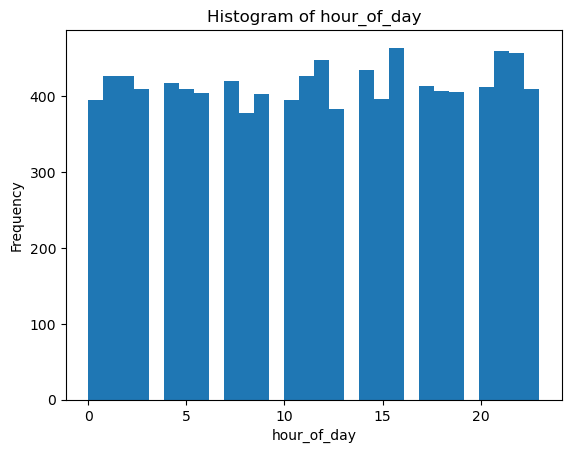

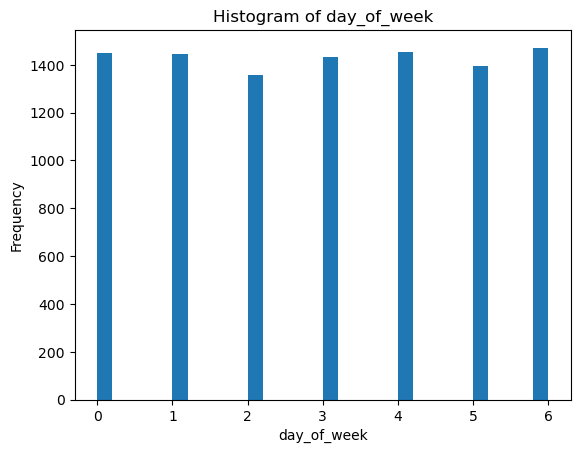

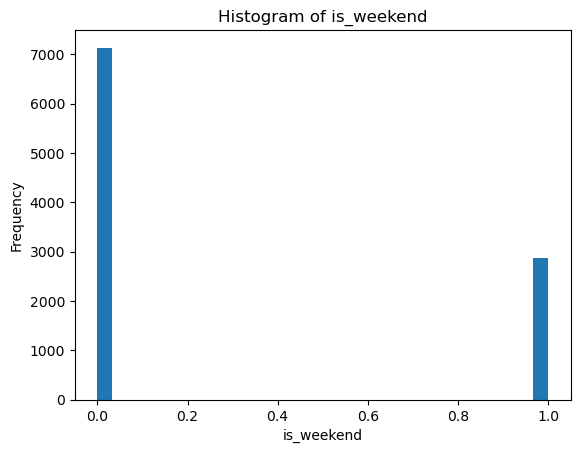

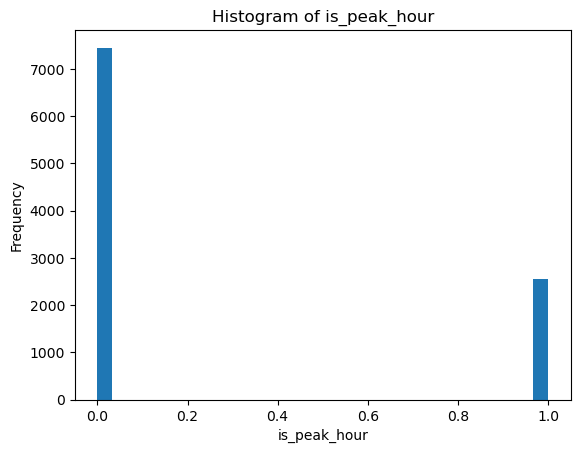

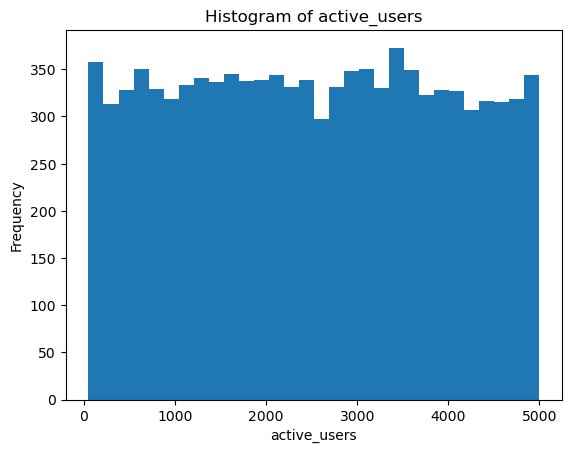

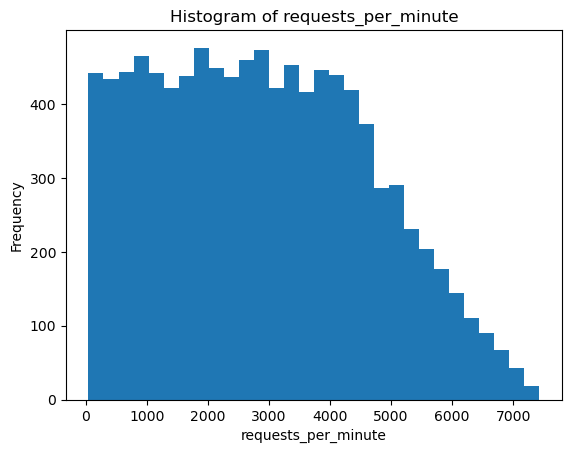

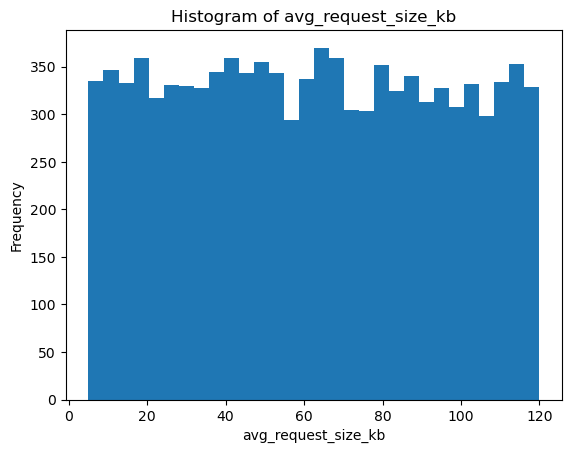

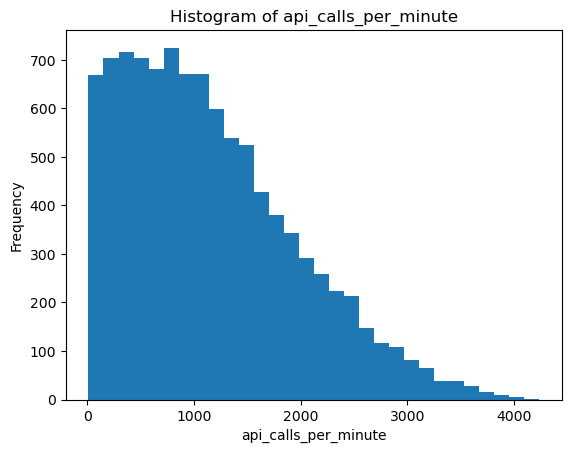

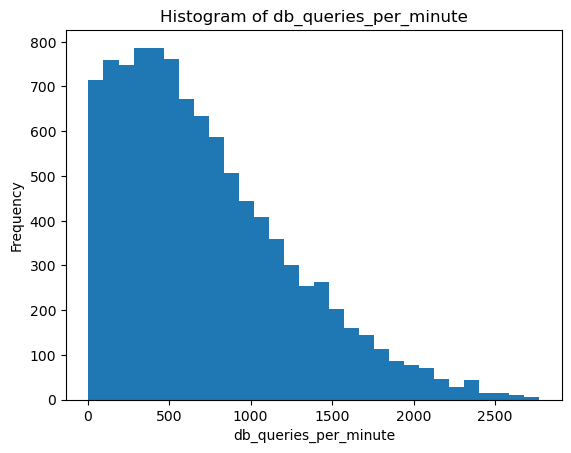

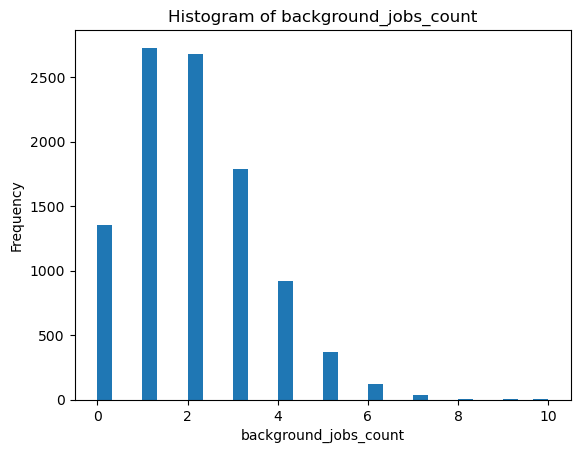

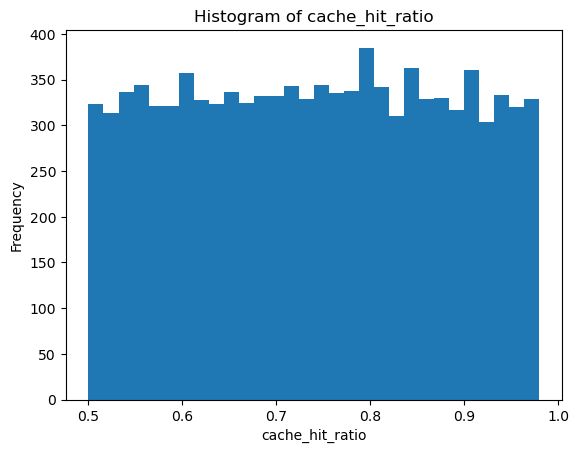

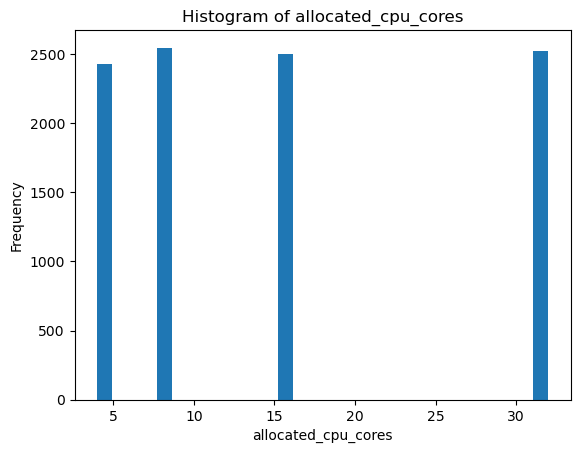

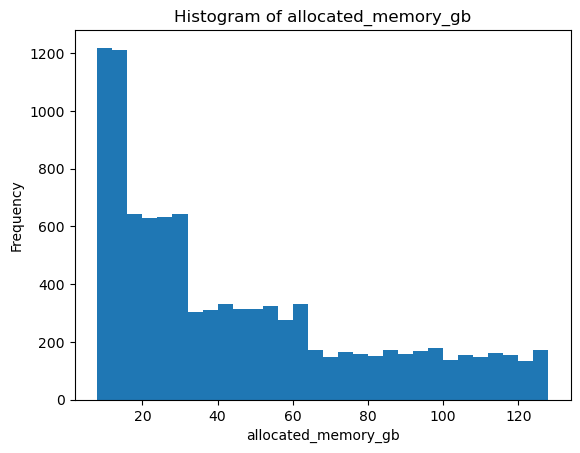

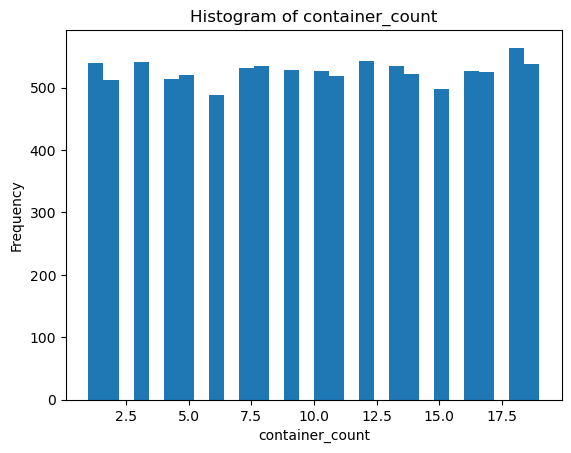

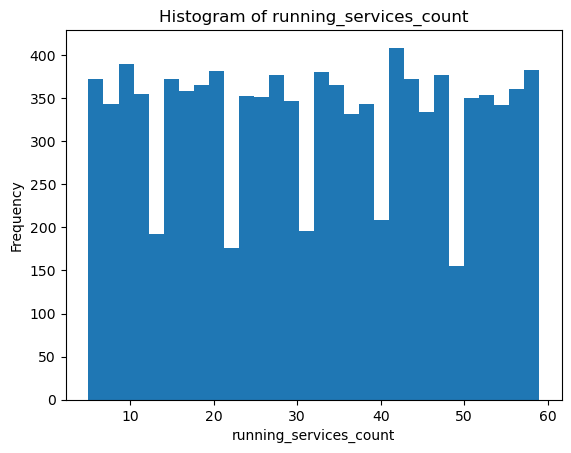

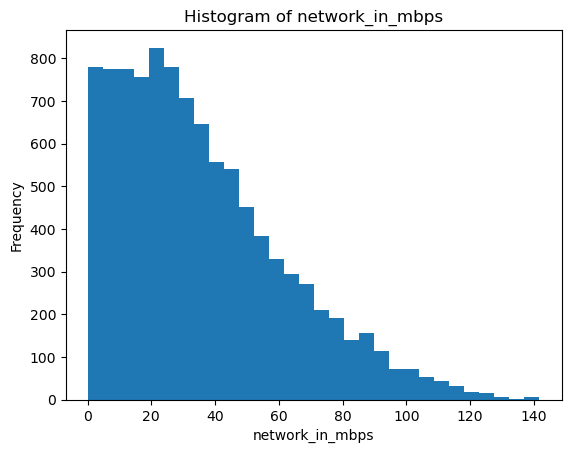

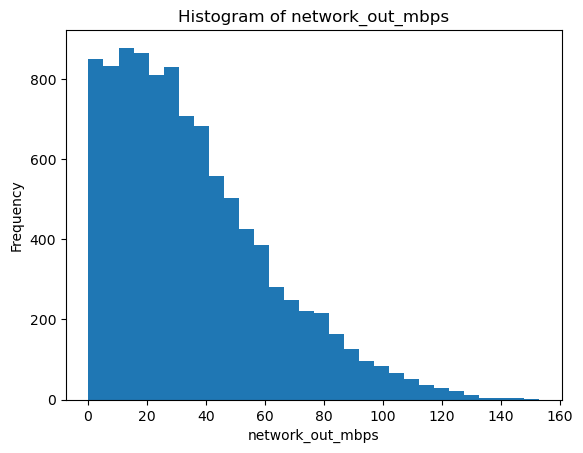

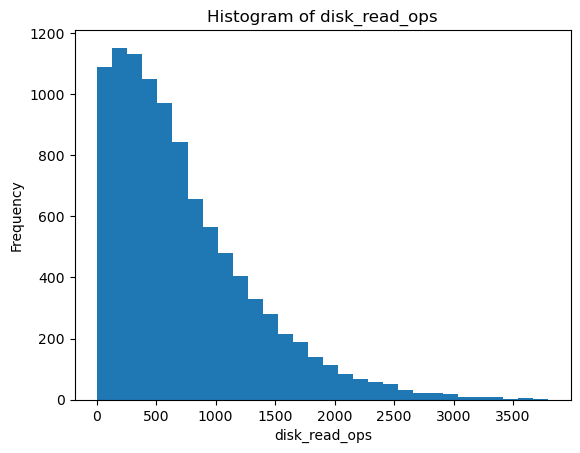

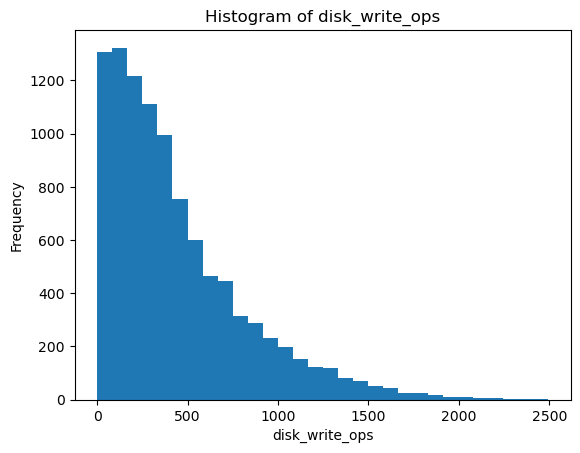

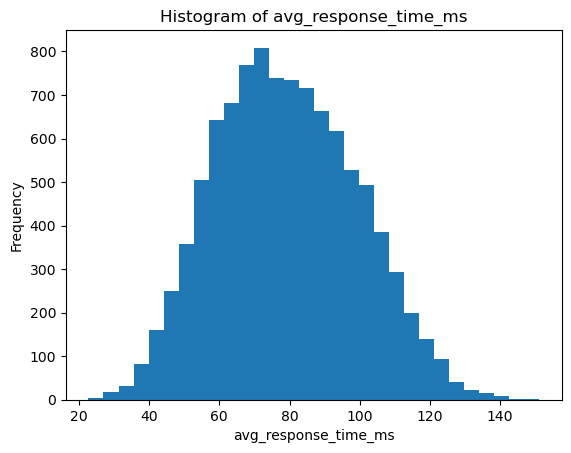

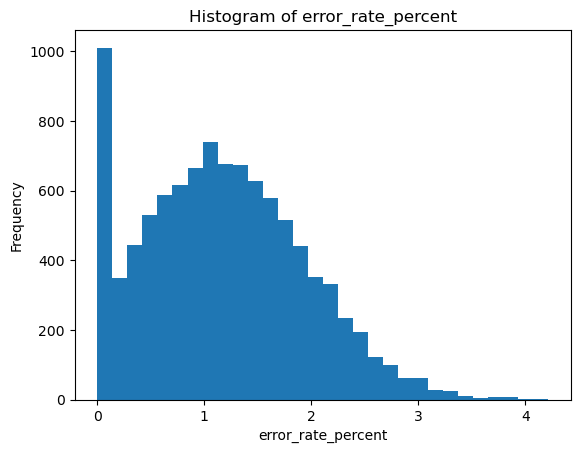

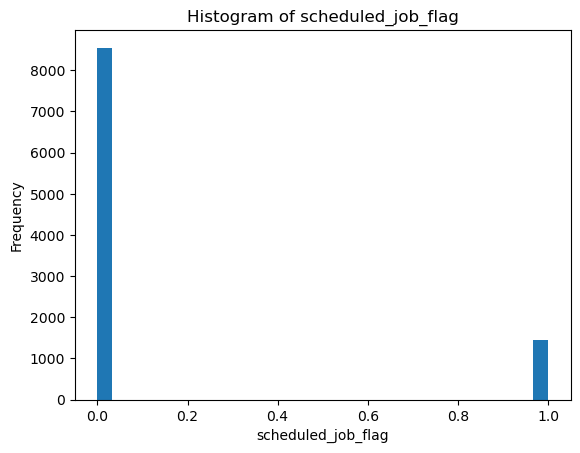

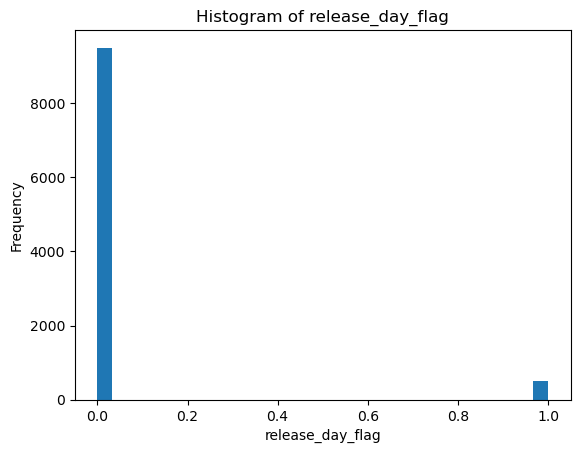

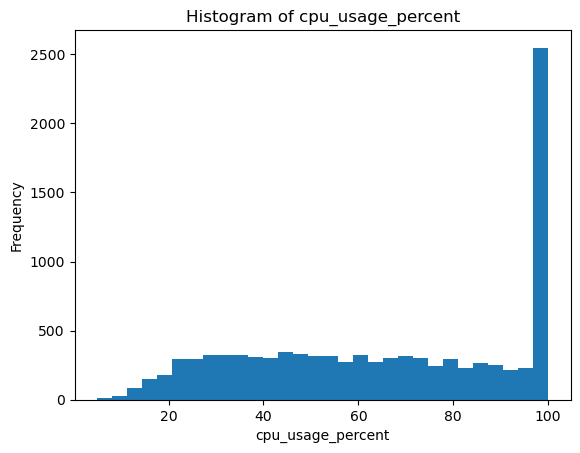

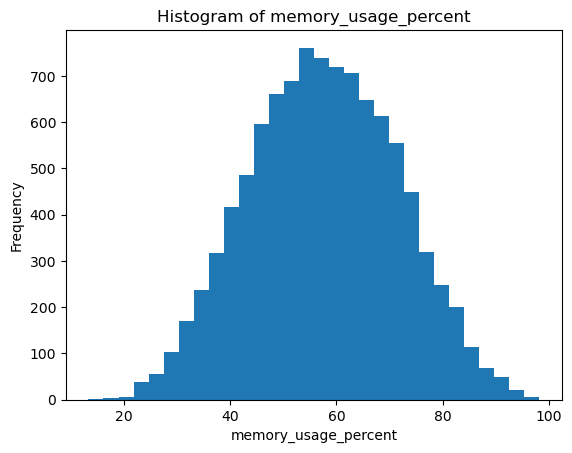

In [11]:
for col in numcol:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

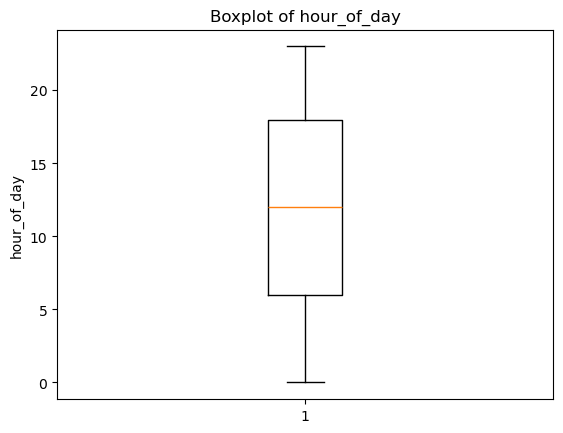

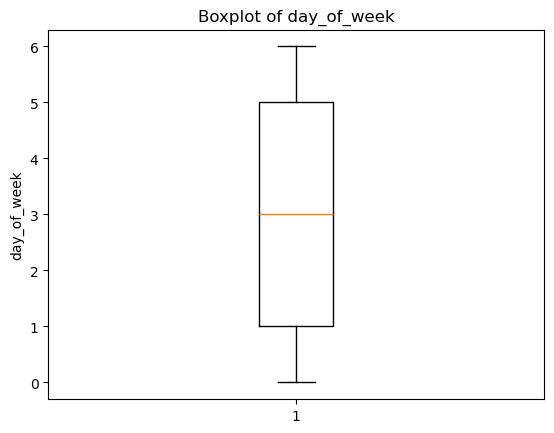

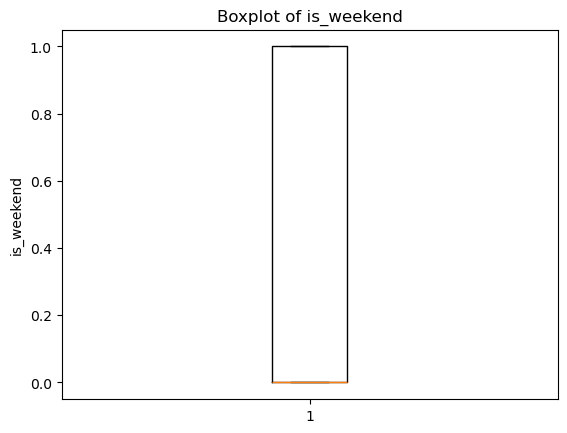

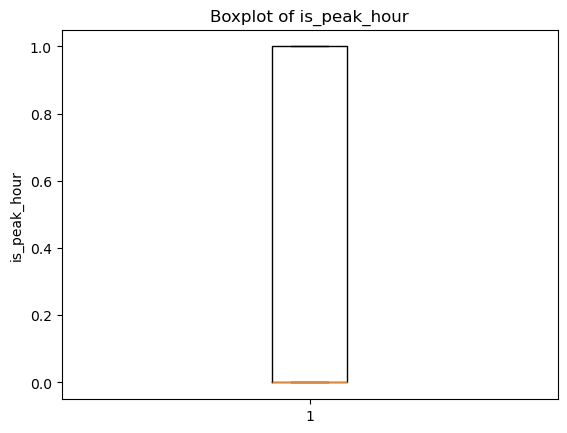

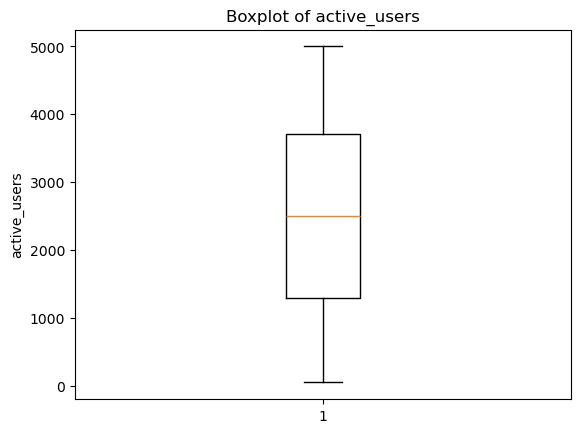

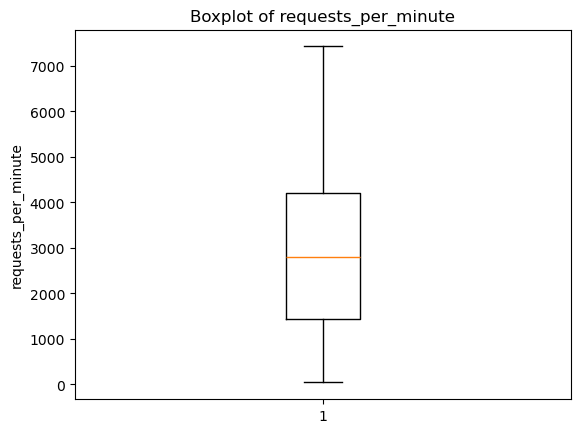

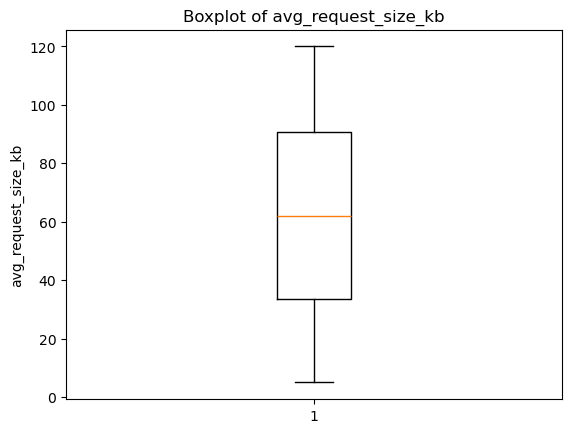

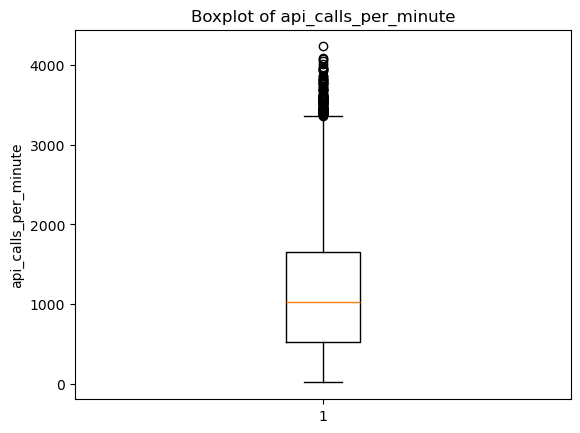

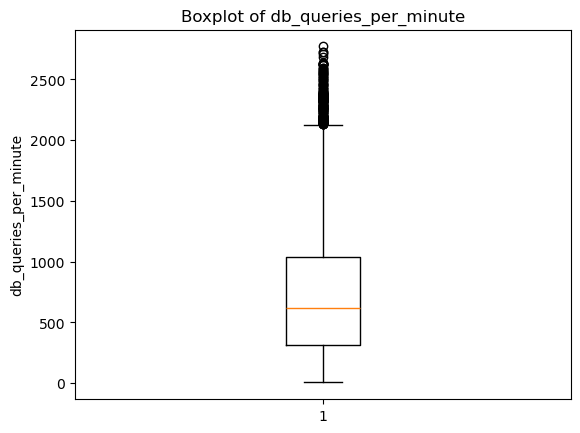

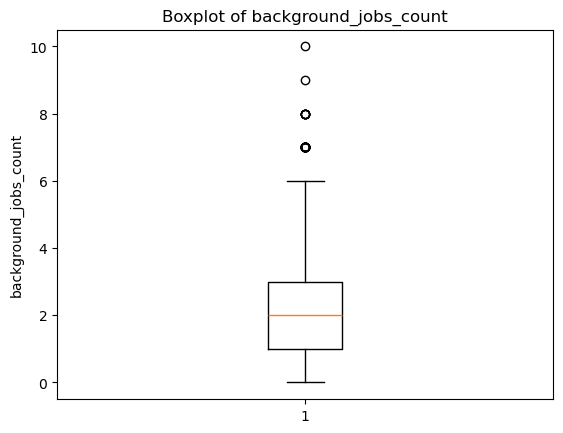

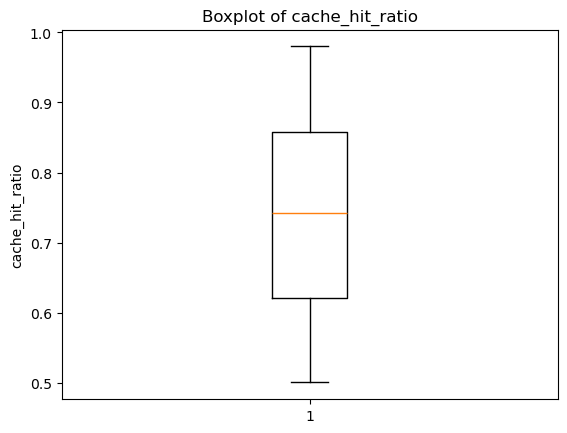

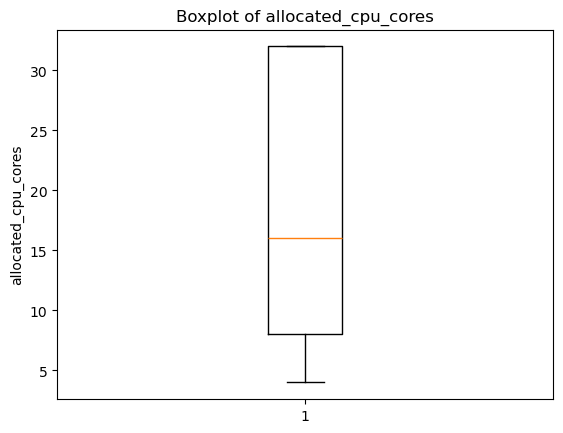

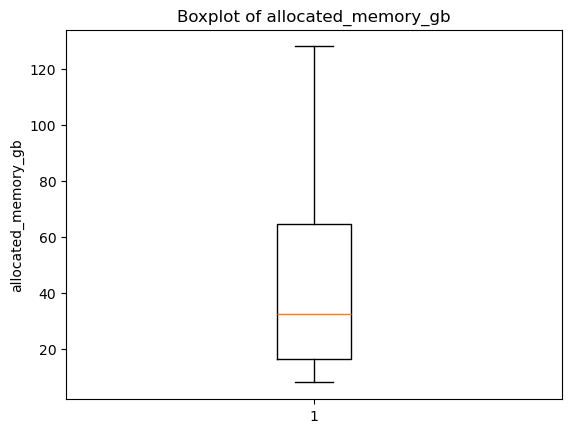

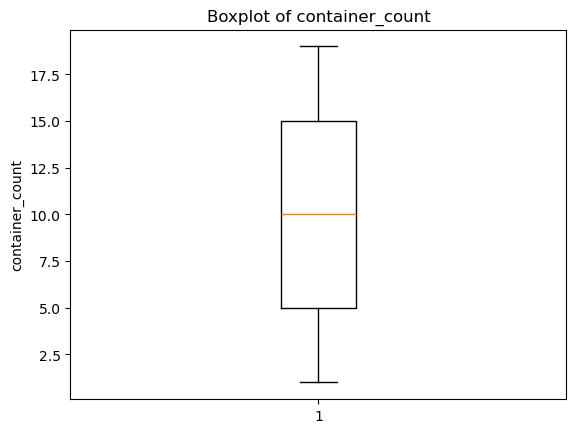

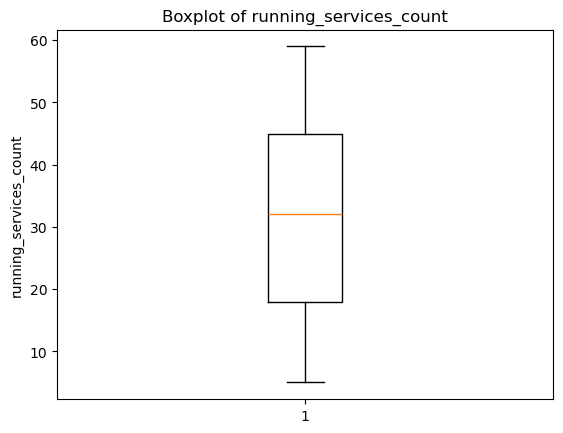

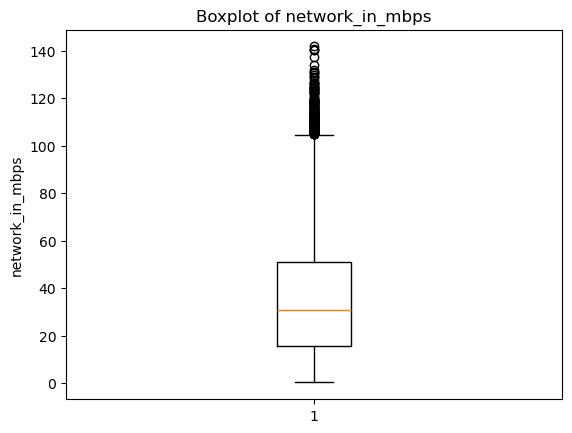

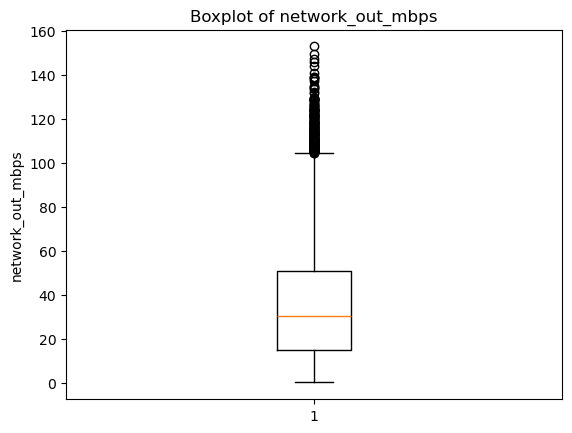

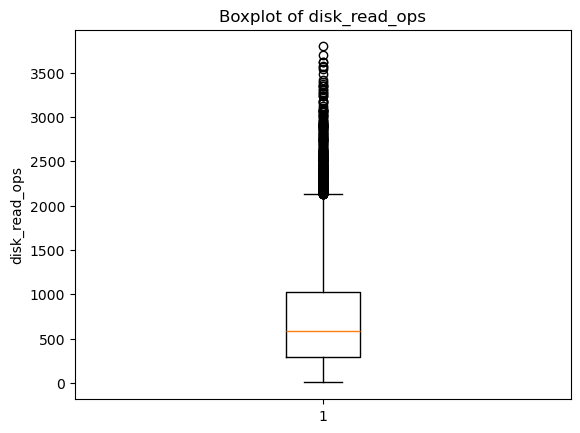

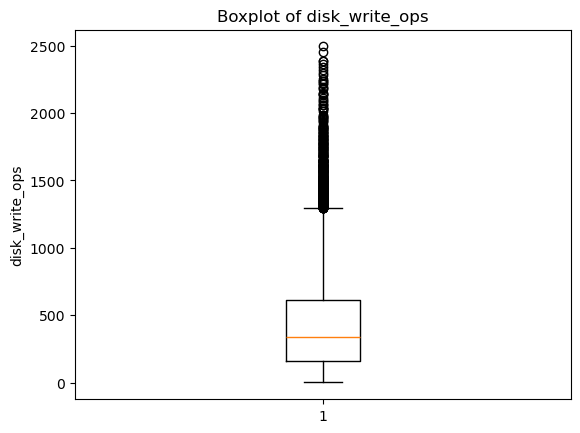

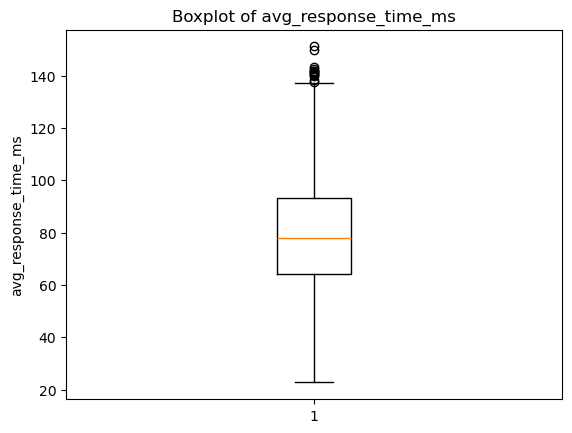

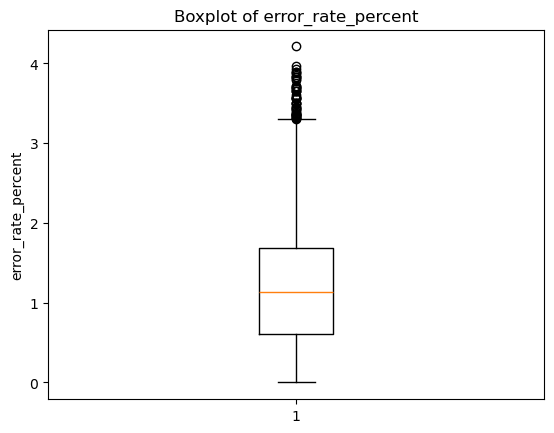

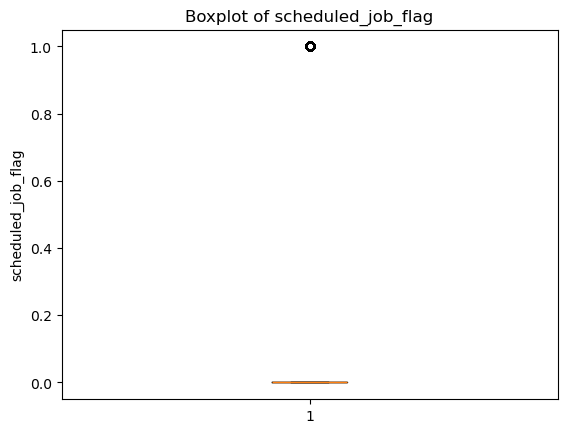

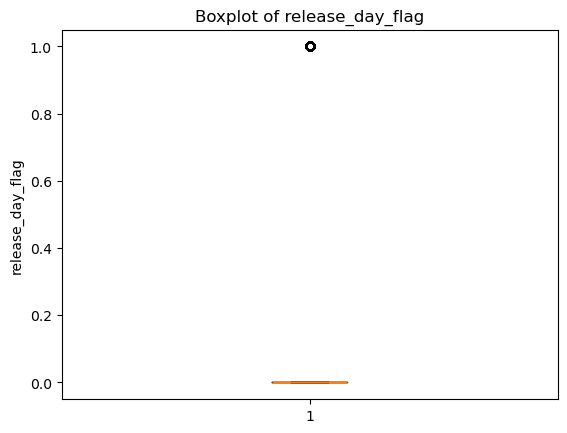

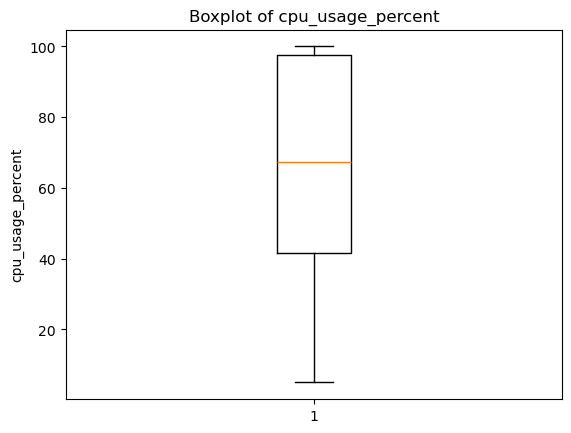

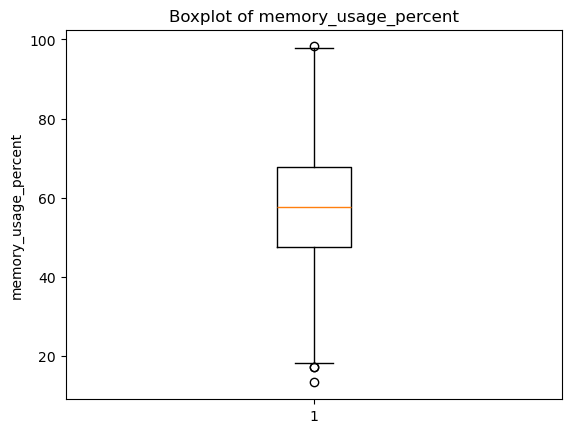

In [12]:
for col in numcol:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


In [13]:
catcol = ['is_weekend','is_peak_hour','scheduled_job_flag','release_day_flag','day_of_week']


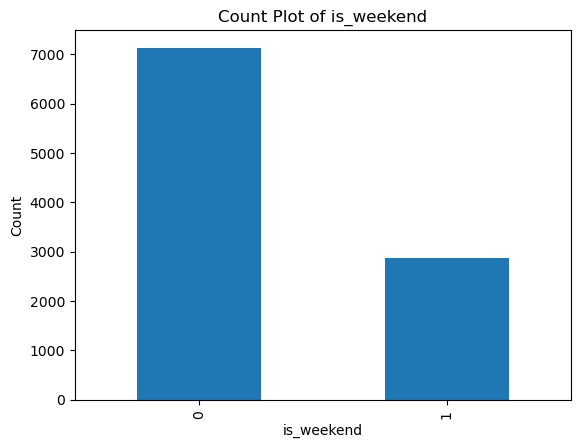

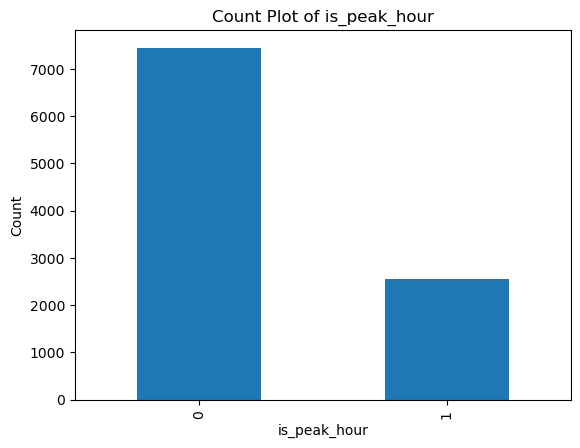

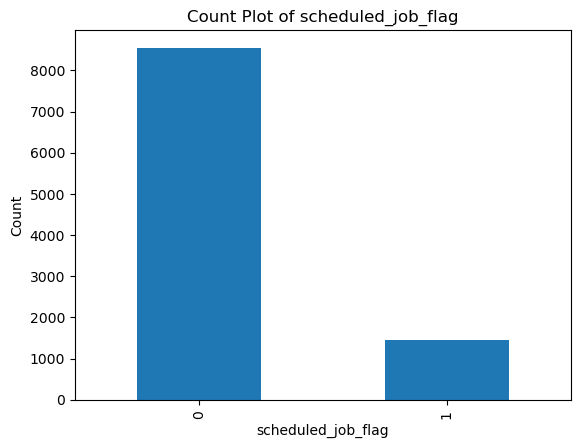

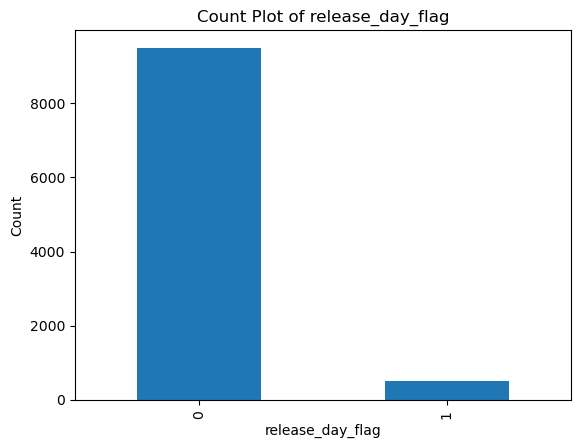

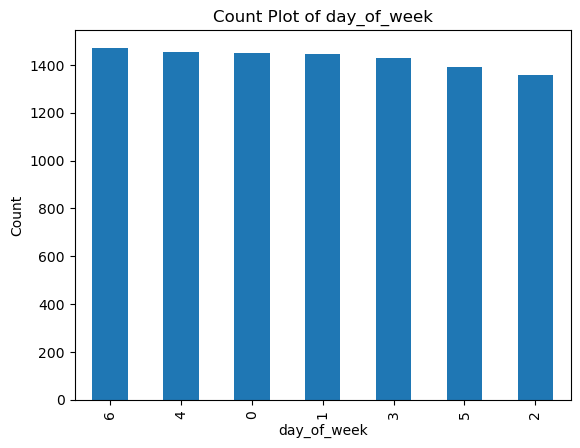

In [14]:
for col in catcol:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [15]:
group_cpu = df.groupby('is_peak_hour')['cpu_usage_percent'].mean()
print("\nCPU Usage by Peak Hour:\n", group_cpu)

group_mem = df.groupby('is_weekend')['memory_usage_percent'].mean()
print("\nMemory Usage by Weekend:\n", group_mem)


CPU Usage by Peak Hour:
 is_peak_hour
0    64.672391
1    69.925954
Name: cpu_usage_percent, dtype: float64

Memory Usage by Weekend:
 is_weekend
0    57.563070
1    57.714677
Name: memory_usage_percent, dtype: float64


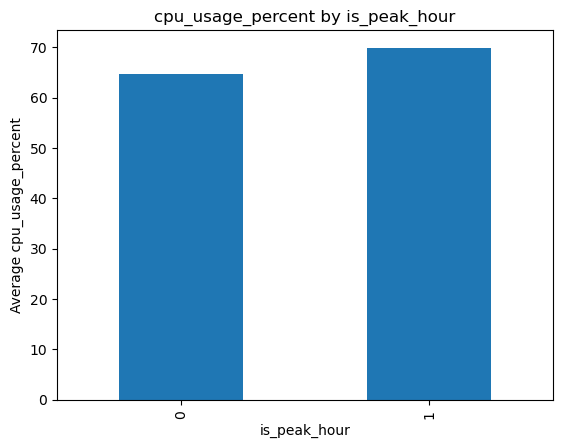

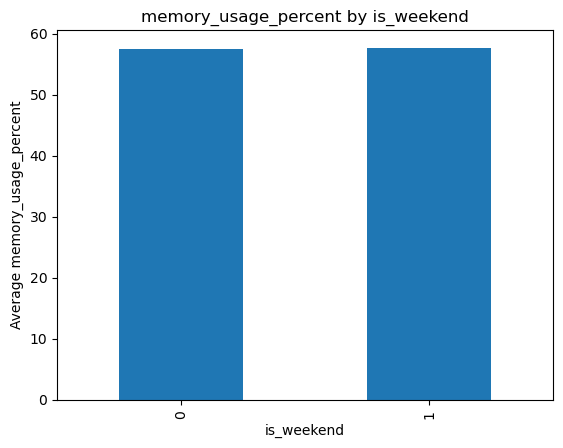

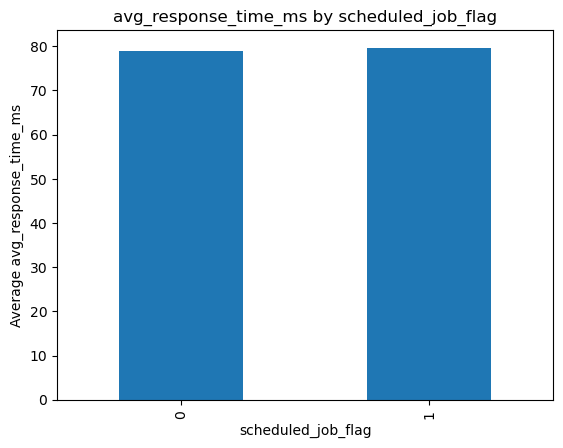

In [16]:
group_features = [
    ('is_peak_hour','cpu_usage_percent'),
    ('is_weekend','memory_usage_percent'),
    ('scheduled_job_flag','avg_response_time_ms')
]

for cat, num in group_features:
    grp = df.groupby(cat)[num].mean()
    plt.figure()
    grp.plot(kind='bar')
    plt.title(f"{num} by {cat}")
    plt.xlabel(cat)
    plt.ylabel(f"Average {num}")
    plt.show()

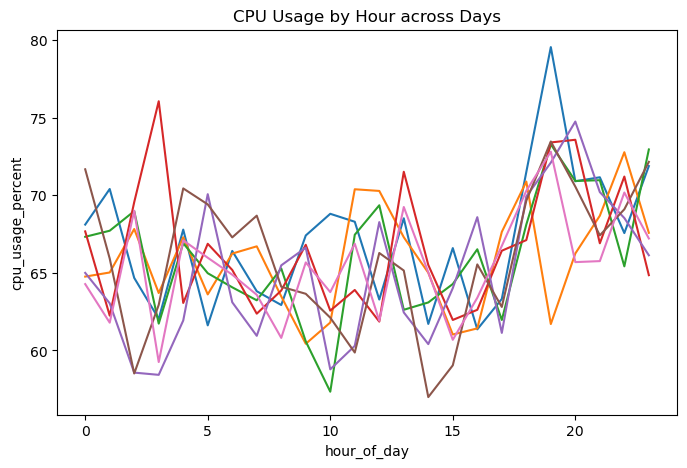

In [17]:
pivot = pd.pivot_table(df, values='cpu_usage_percent', index='hour_of_day', columns='day_of_week')

plt.figure(figsize=(8,5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col])
plt.title("CPU Usage by Hour across Days")
plt.xlabel("hour_of_day")
plt.ylabel("cpu_usage_percent")
plt.show()

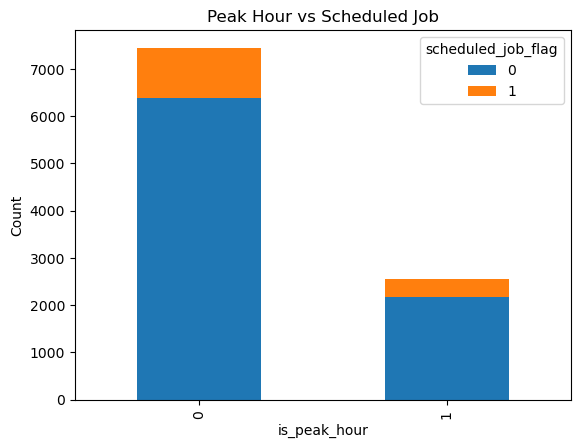

In [18]:
ct = pd.crosstab(df['is_peak_hour'], df['scheduled_job_flag'])

ct.plot(kind='bar', stacked=True)
plt.title("Peak Hour vs Scheduled Job")
plt.xlabel("is_peak_hour")
plt.ylabel("Count")
plt.show()

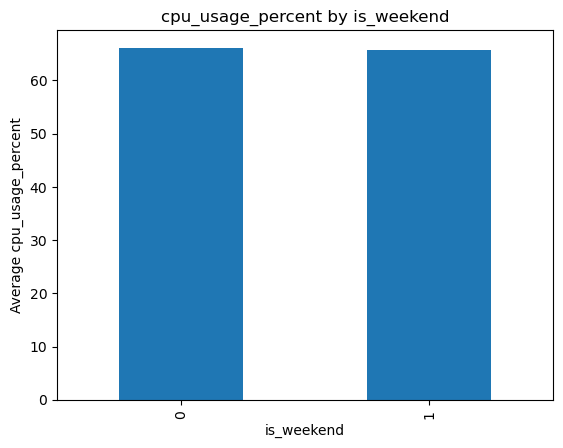

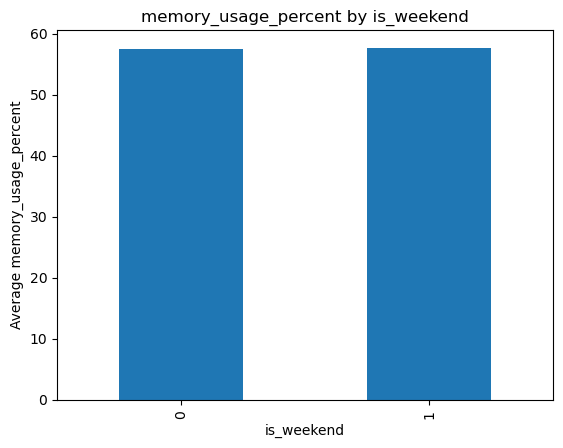

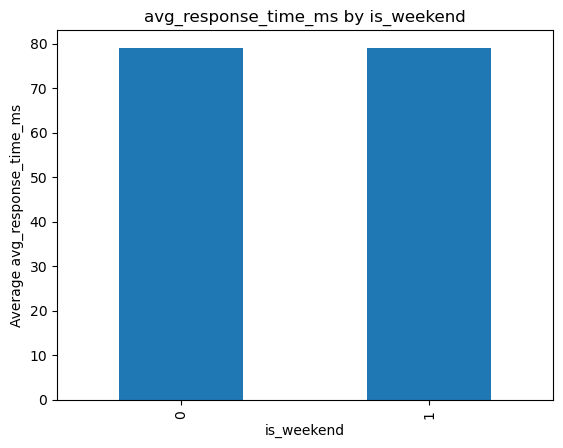

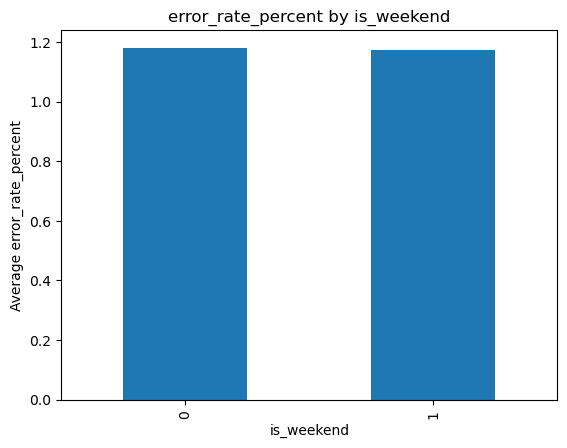

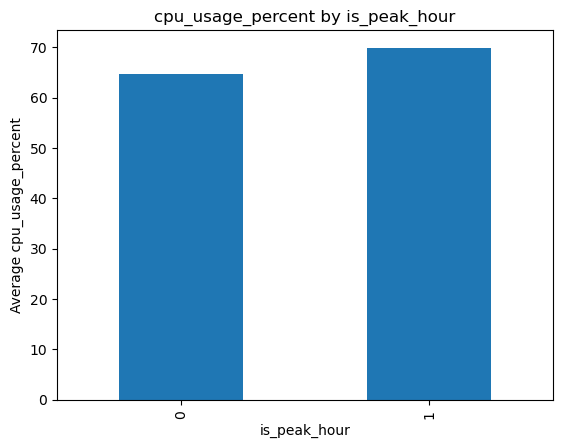

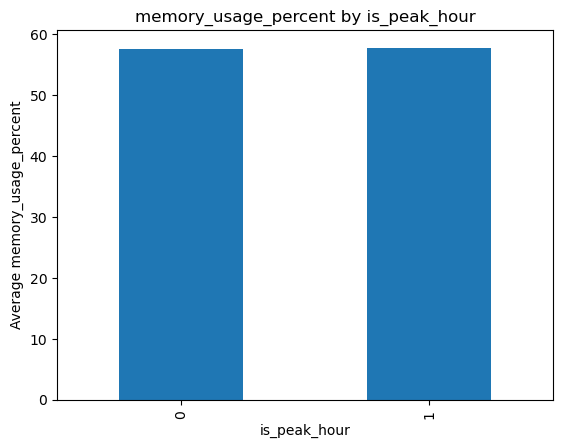

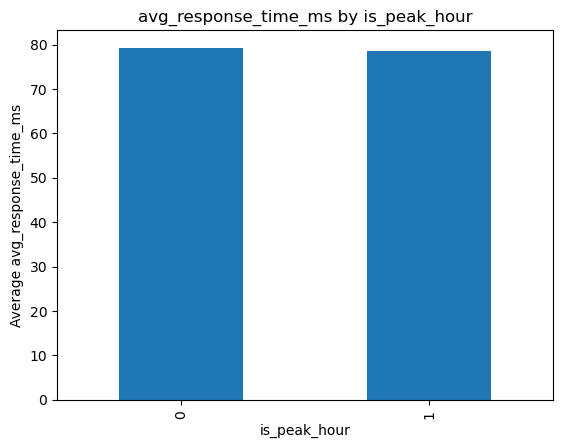

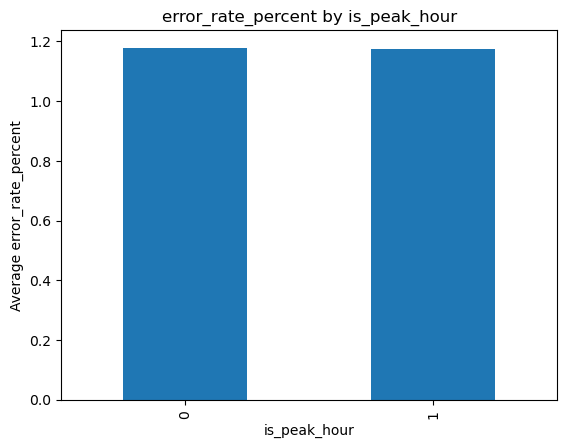

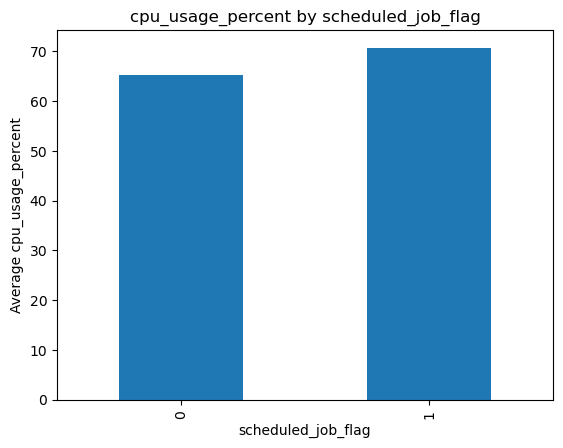

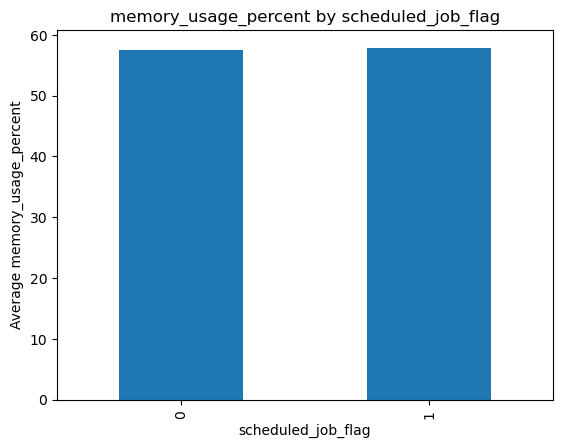

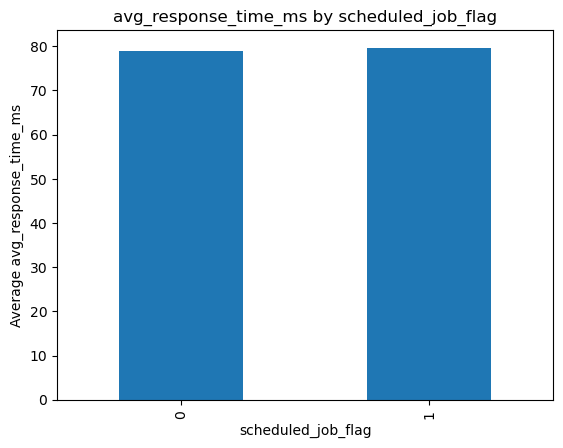

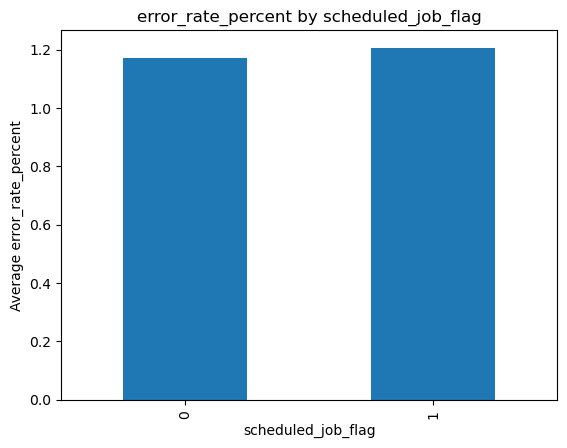

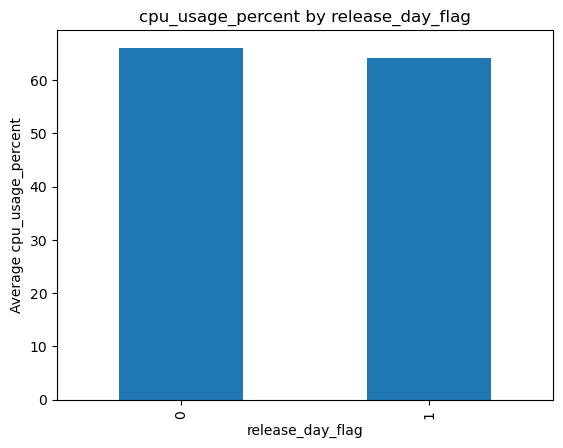

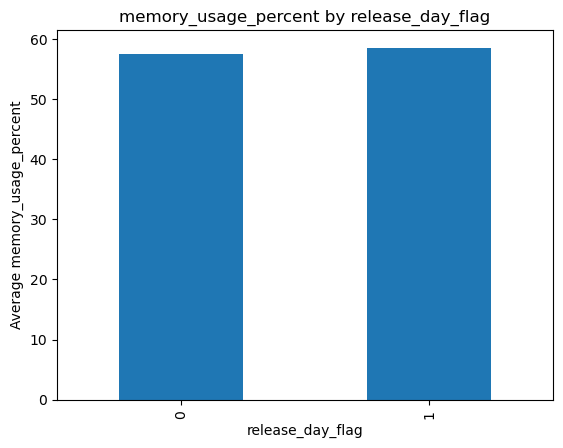

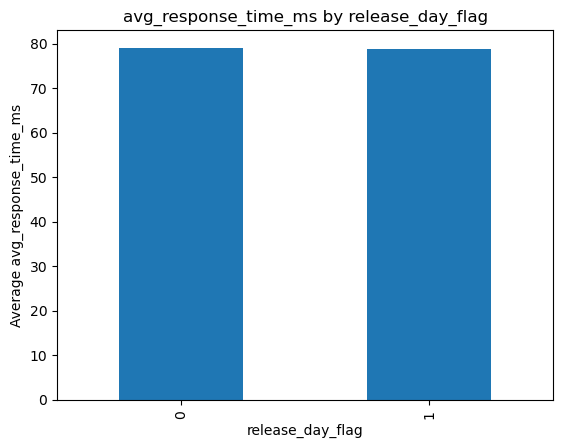

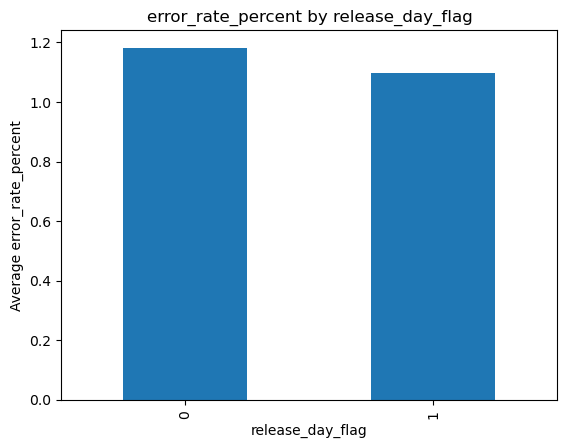

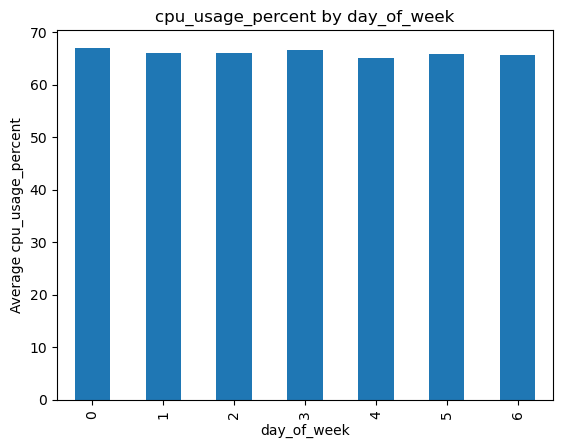

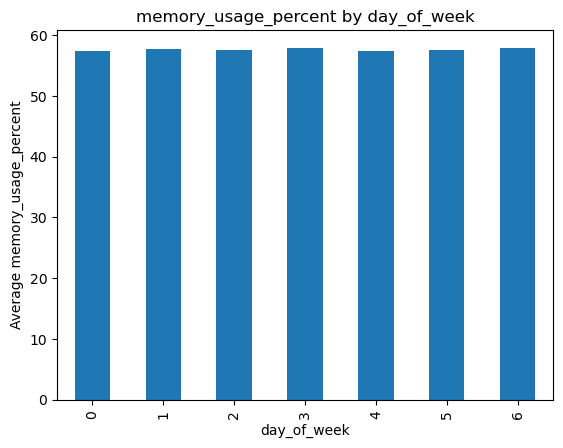

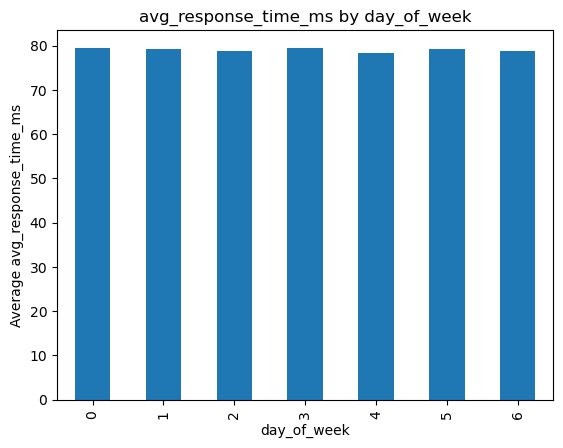

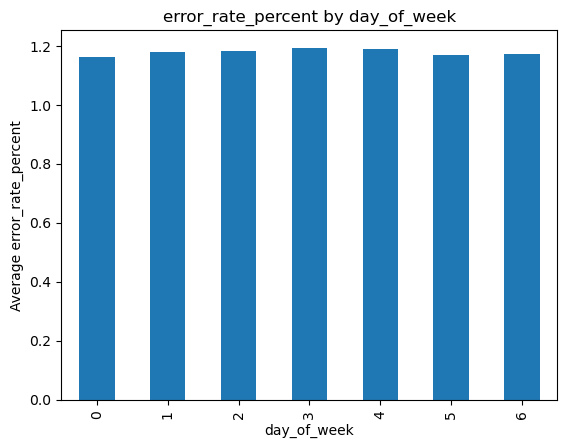

In [19]:
for cat in catcol:
    for num in ['cpu_usage_percent','memory_usage_percent','avg_response_time_ms','error_rate_percent']:
        plt.figure()
        df.groupby(cat)[num].mean().plot(kind='bar')
        plt.title(f"{num} by {cat}")
        plt.xlabel(cat)
        plt.ylabel(f"Average {num}")
        plt.show()


<Figure size 640x480 with 0 Axes>

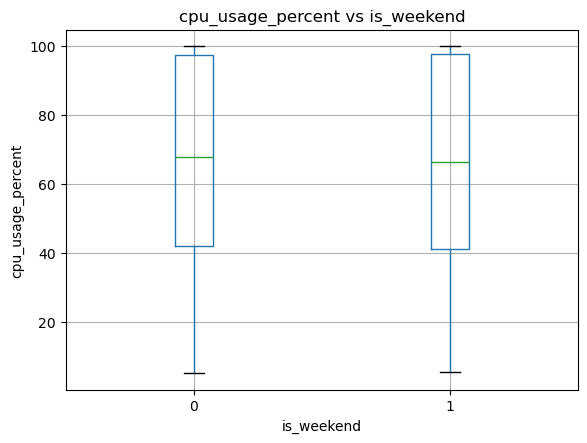

<Figure size 640x480 with 0 Axes>

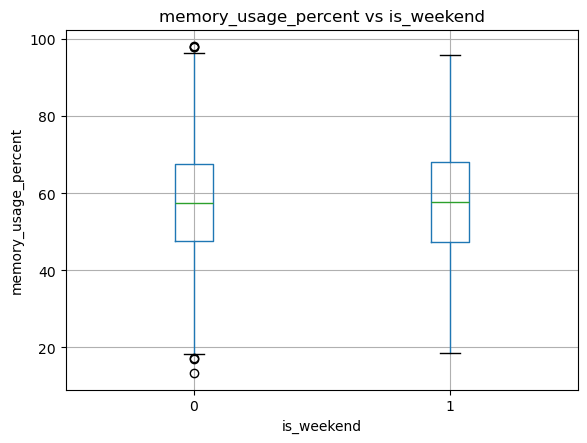

<Figure size 640x480 with 0 Axes>

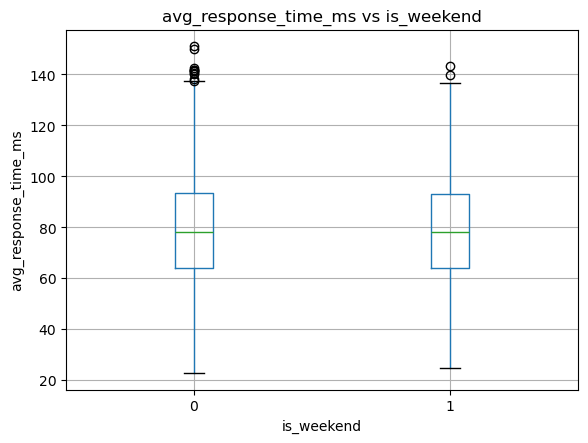

<Figure size 640x480 with 0 Axes>

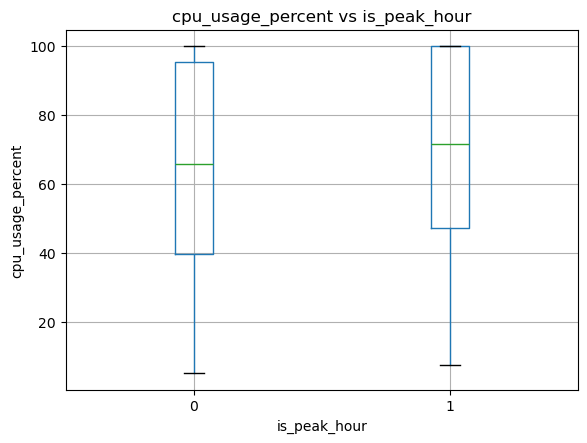

<Figure size 640x480 with 0 Axes>

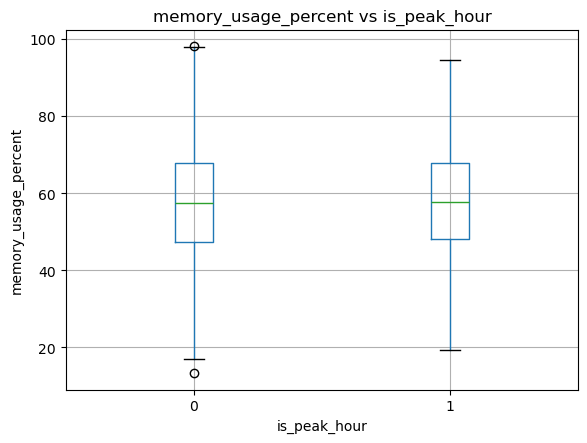

<Figure size 640x480 with 0 Axes>

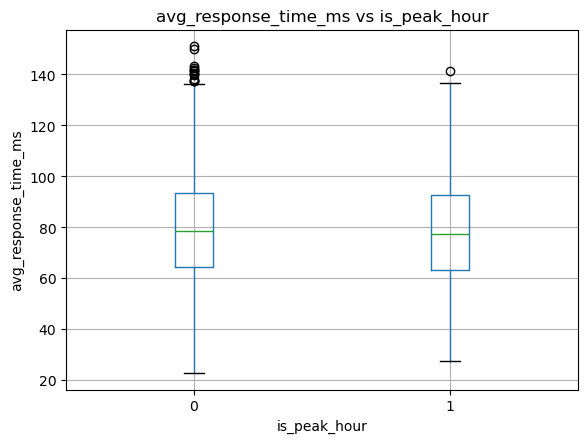

<Figure size 640x480 with 0 Axes>

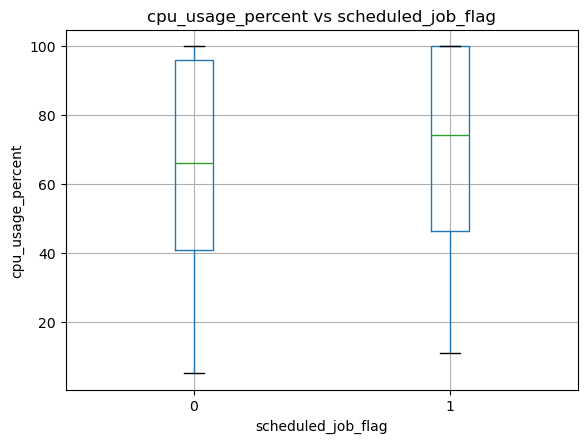

<Figure size 640x480 with 0 Axes>

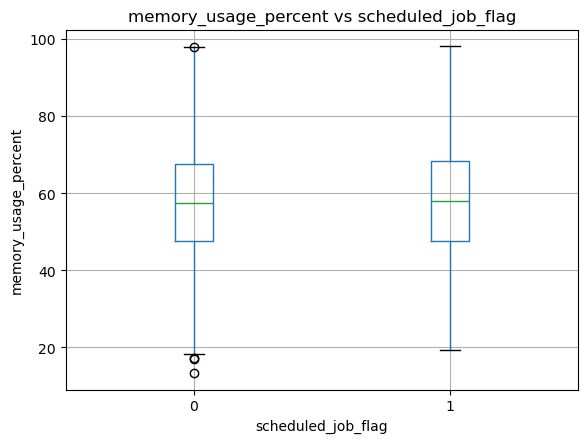

<Figure size 640x480 with 0 Axes>

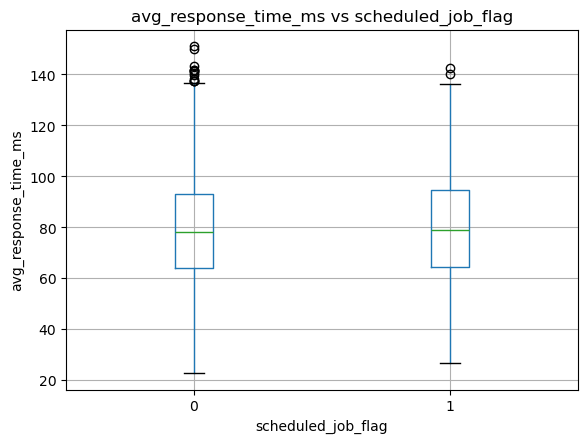

<Figure size 640x480 with 0 Axes>

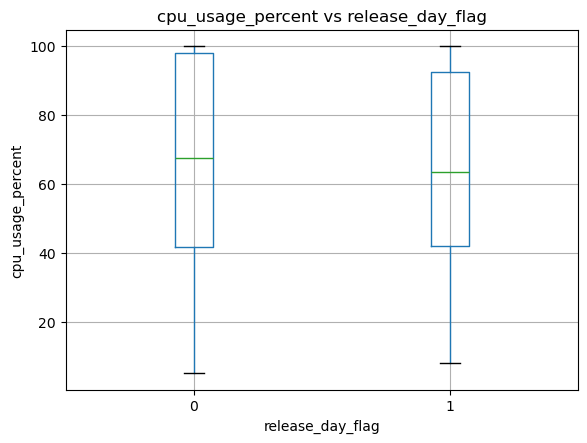

<Figure size 640x480 with 0 Axes>

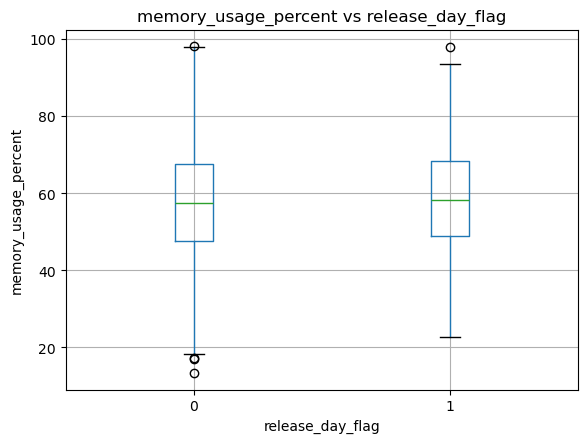

<Figure size 640x480 with 0 Axes>

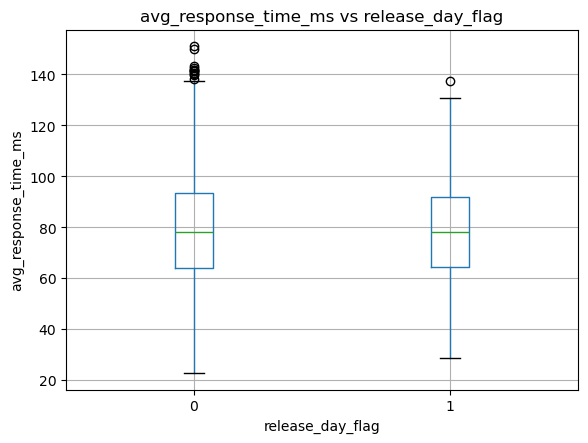

<Figure size 640x480 with 0 Axes>

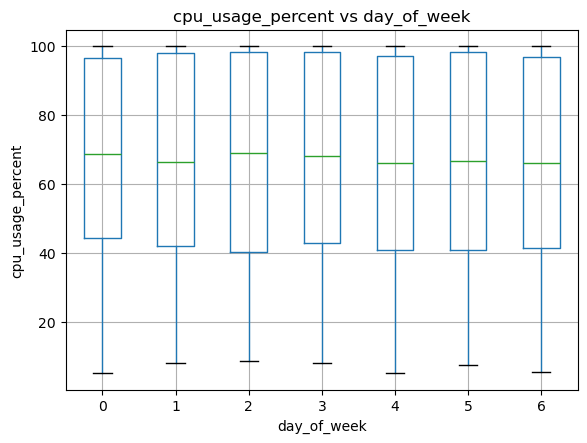

<Figure size 640x480 with 0 Axes>

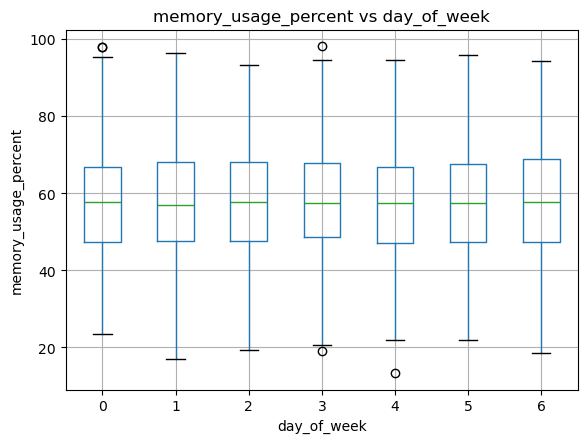

<Figure size 640x480 with 0 Axes>

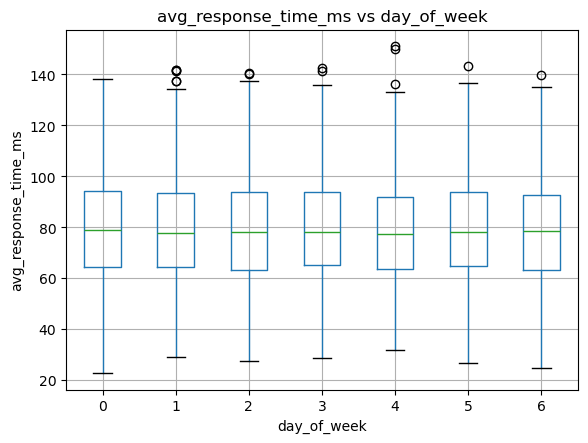

In [20]:
for cat in catcol:
    for num in ['cpu_usage_percent','memory_usage_percent','avg_response_time_ms']:
        plt.figure()
        df.boxplot(column=num, by=cat)
        plt.title(f"{num} vs {cat}")
        plt.suptitle("")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

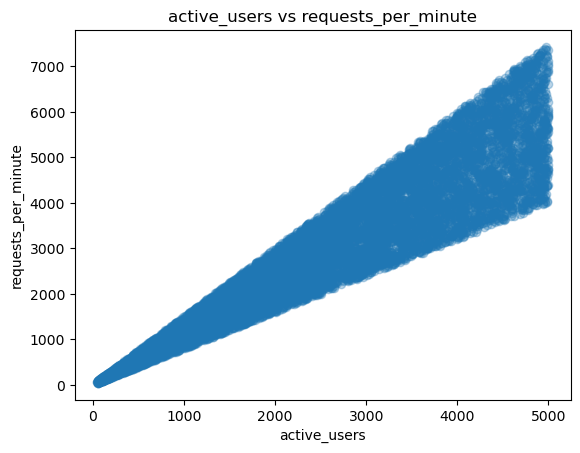

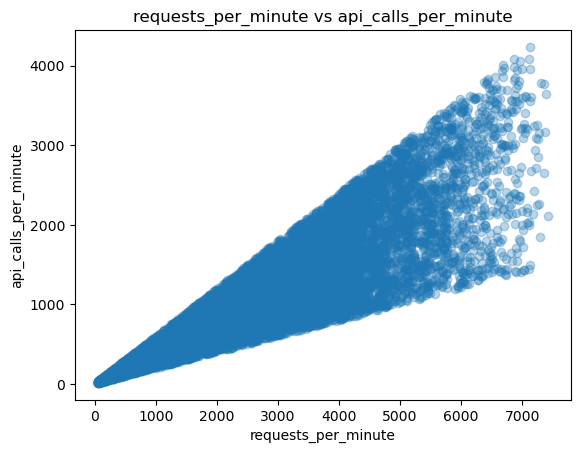

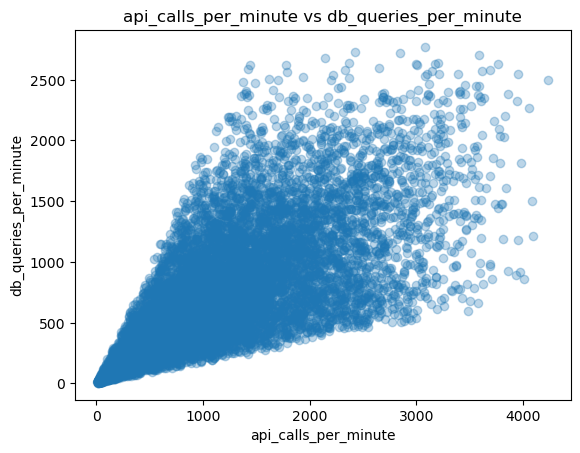

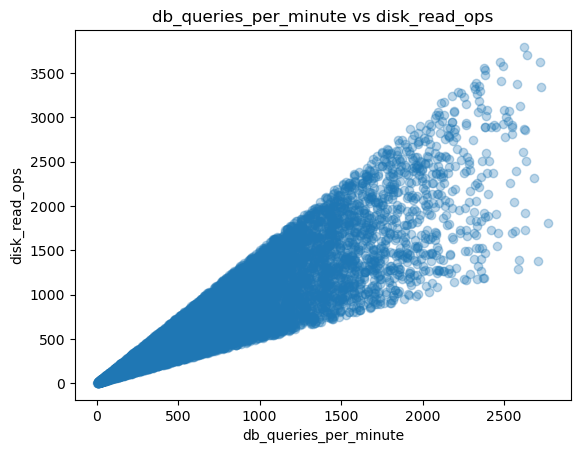

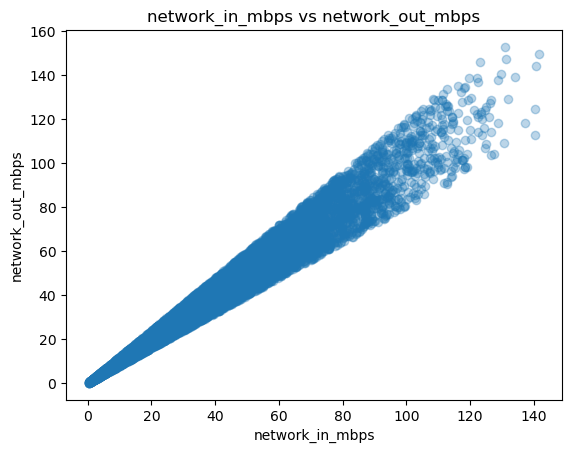

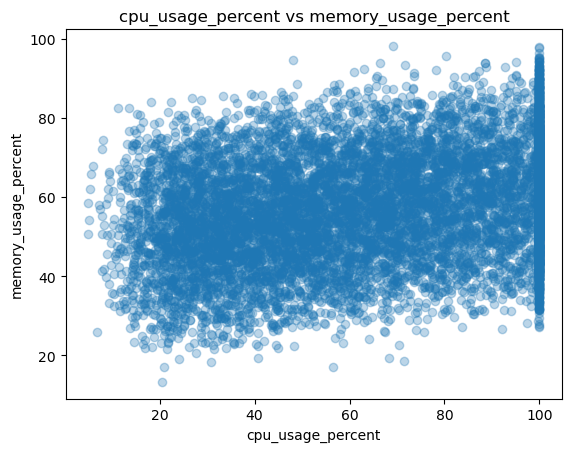

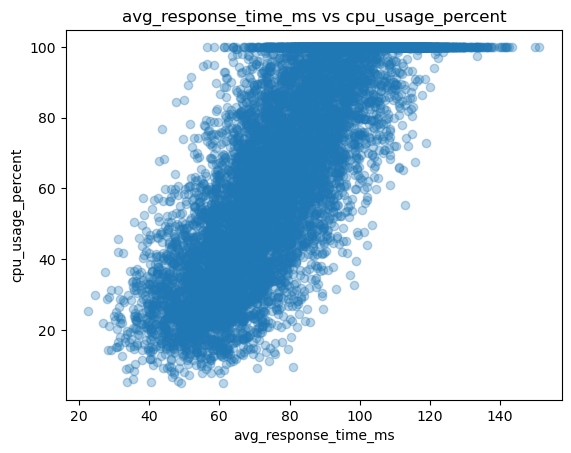

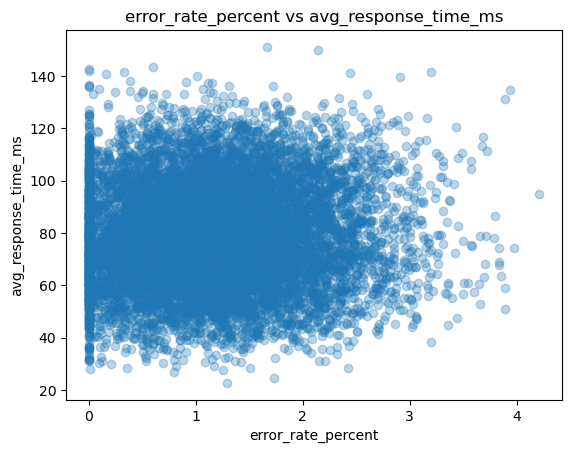

In [21]:
pairs = [
    ('active_users','requests_per_minute'),
    ('requests_per_minute','api_calls_per_minute'),
    ('api_calls_per_minute','db_queries_per_minute'),
    ('db_queries_per_minute','disk_read_ops'),
    ('network_in_mbps','network_out_mbps'),
    ('cpu_usage_percent','memory_usage_percent'),
    ('avg_response_time_ms','cpu_usage_percent'),
    ('error_rate_percent','avg_response_time_ms')
]

for x, y in pairs:
    plt.figure()
    plt.scatter(df[x], df[y], alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")
    plt.show()

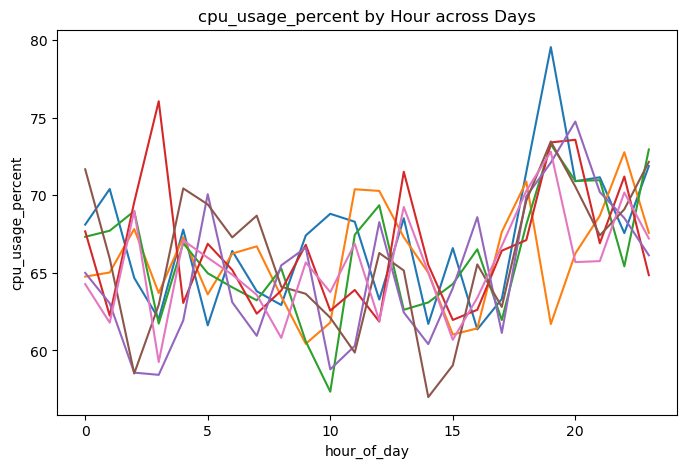

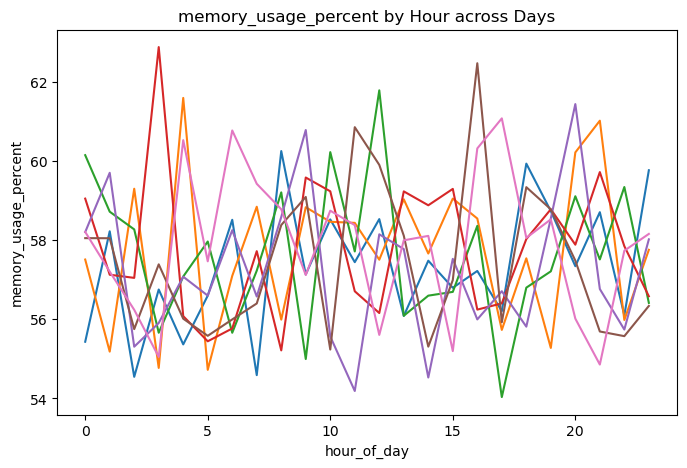

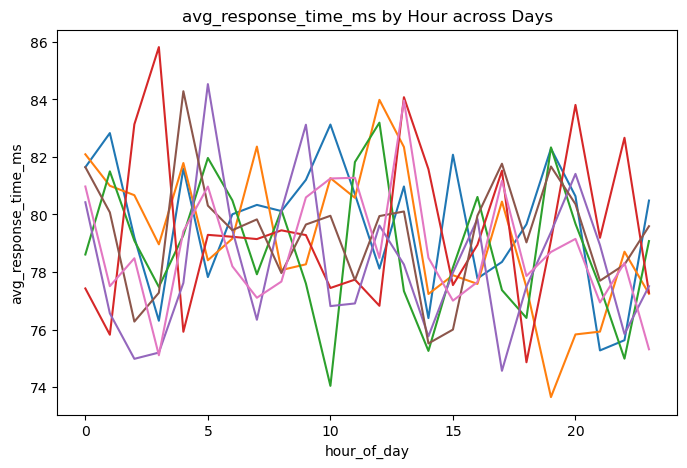

In [22]:
pivot_metrics = ['cpu_usage_percent','memory_usage_percent','avg_response_time_ms']

for metric in pivot_metrics:
    pivot = pd.pivot_table(df, values=metric, index='hour_of_day', columns='day_of_week')
    
    plt.figure(figsize=(8,5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col])
    plt.title(f"{metric} by Hour across Days")
    plt.xlabel("hour_of_day")
    plt.ylabel(metric)
    plt.show()

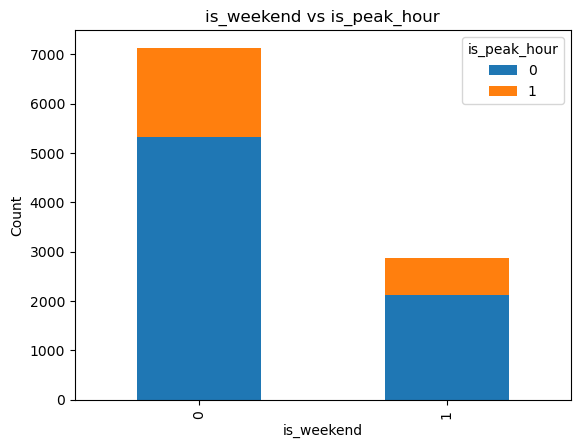

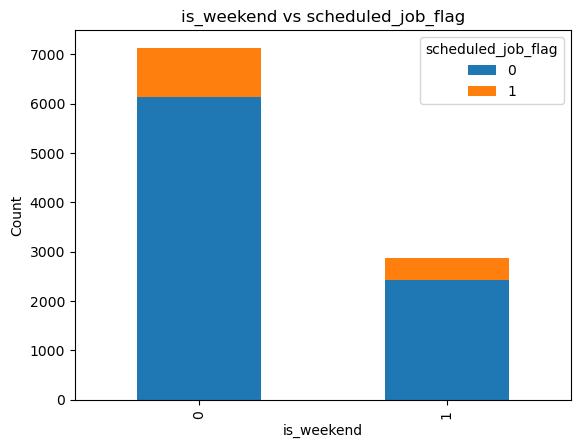

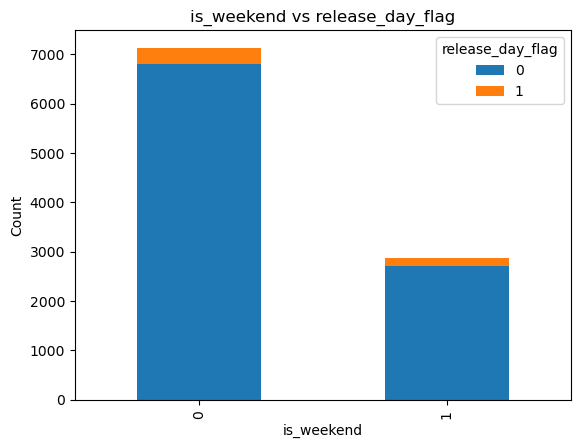

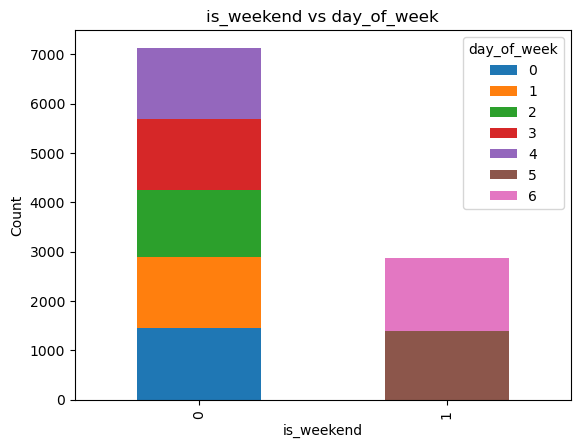

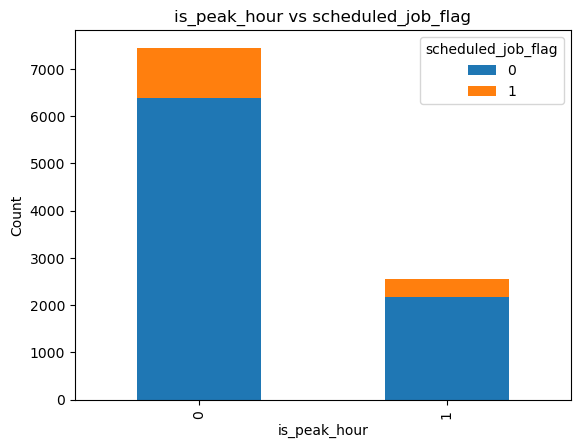

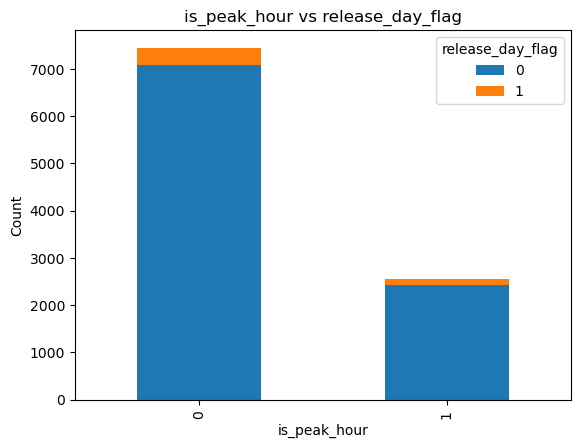

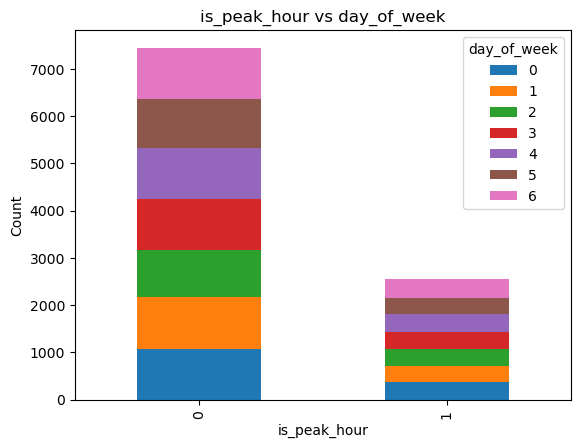

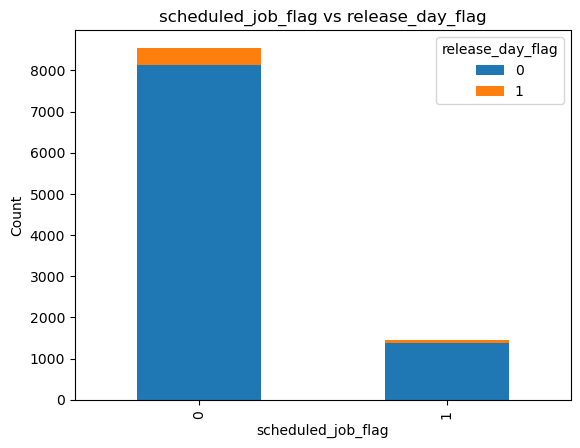

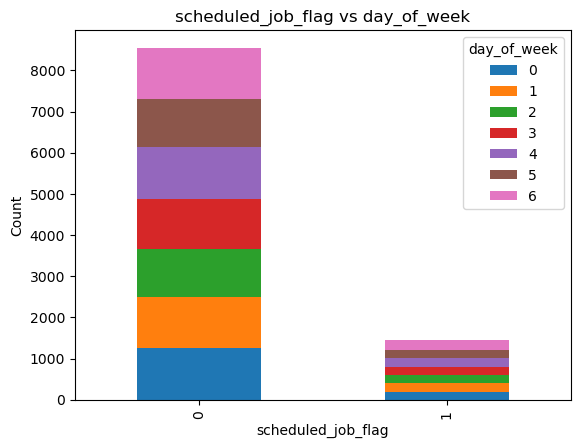

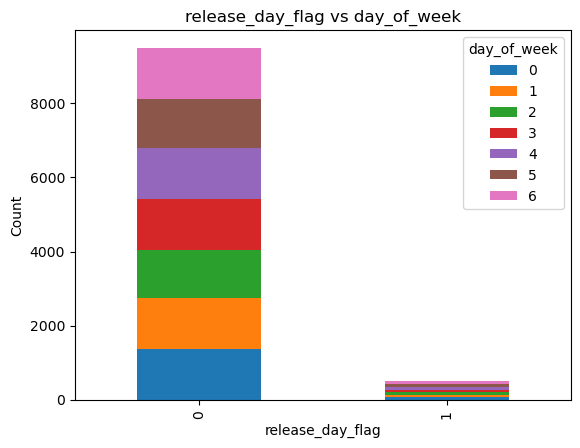

In [24]:
import itertools
cat_pairs = list(itertools.combinations(catcol, 2))

for c1, c2 in cat_pairs:
    ct = pd.crosstab(df[c1], df[c2])
    ct.plot(kind='bar', stacked=True)
    plt.title(f"{c1} vs {c2}")
    plt.xlabel(c1)
    plt.ylabel("Count")
    plt.show()

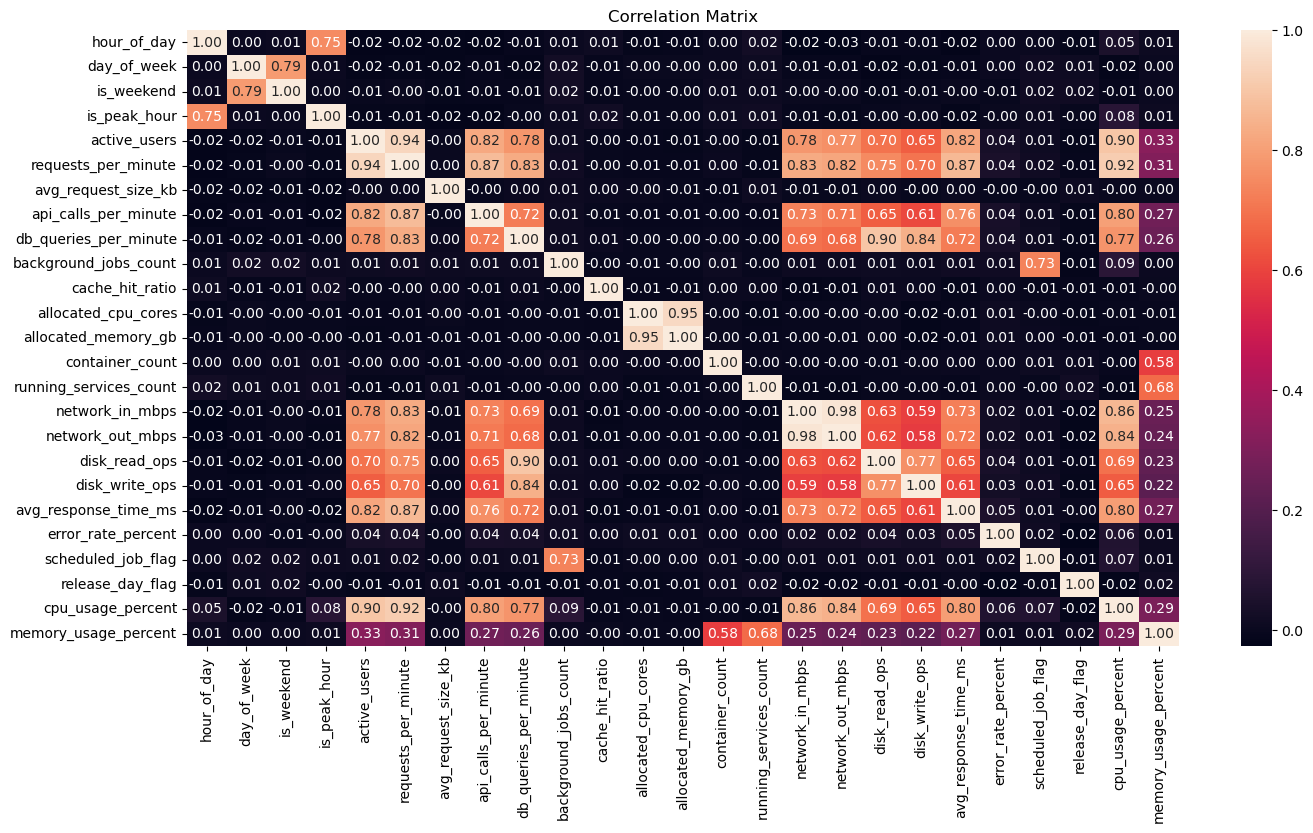

In [30]:
corr = df[numcol].corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## EDA Insights

### Data Quality and Structure

* The dataset contains 10,000 records and 25 features.
* All features are numerical, including binary categorical flags.
* No missing values or duplicate records are present.
* The dataset is clean and suitable for analysis and modeling without preprocessing for missing data.

---

### Distribution of Variables

* Features such as `memory_usage_percent` and `avg_response_time_ms` follow approximately normal distributions, indicating stable behavior.
* Variables like `requests_per_minute`, `api_calls_per_minute`, `db_queries_per_minute`, `network_in_mbps`, and `disk_read_ops` are right-skewed, showing that most observations are low with occasional high spikes.
* `hour_of_day`, `day_of_week`, and `active_users` are relatively uniformly distributed.
* `cpu_usage_percent` shows a concentration at 100%, indicating saturation, where the system frequently reaches maximum CPU capacity.

---

### Outlier Analysis

* Significant outliers are observed in:

  * `api_calls_per_minute`
  * `db_queries_per_minute`
  * `network_in_mbps`, `network_out_mbps`
  * `disk_read_ops`, `disk_write_ops`
  * `avg_response_time_ms`
  * `error_rate_percent`
* These outliers represent sudden spikes in traffic or workload.
* Features such as `memory_usage_percent` and `cache_hit_ratio` show relatively stable behavior with fewer extreme values.

---

### Relationship Between Variables

#### Numerical Relationships

* Strong positive relationships are observed between:

  * `active_users` and `cpu_usage_percent`
  * `requests_per_minute` and `cpu_usage_percent`
  * `network_in_mbps` and `cpu_usage_percent`
  * `db_queries_per_minute` and `disk_read_ops`
* These relationships indicate that system load is directly driven by user activity and request volume.

#### System Flow Behavior

* A clear dependency chain is visible:

  * active users → requests → API calls → database queries → disk operations
* This reflects how workload propagates through different system components.

---

### Categorical Impact on Performance

* `is_peak_hour`:

  * Higher average CPU usage and response time during peak hours.
* `scheduled_job_flag`:

  * Increased response time and slight increase in CPU usage when background jobs are running.
* `is_weekend`:

  * Minimal impact on CPU and memory usage.
* `release_day_flag`:

  * Occurs infrequently and has limited overall impact.

---

### Correlation and Multicollinearity

* Strong correlations exist among:

  * `active_users`, `requests_per_minute`, `api_calls_per_minute`
  * `db_queries_per_minute` and `disk_read_ops`
  * `network_in_mbps` and `network_out_mbps`
* This indicates multicollinearity, where multiple features carry similar information.

---

### Important Features

* Highly influential features for predicting system load:

  * `requests_per_minute`
  * `active_users`
  * `api_calls_per_minute`
  * `db_queries_per_minute`
  * `network_in_mbps`

* Moderately influential features:

  * `background_jobs_count`
  * `cache_hit_ratio`
  * `avg_request_size_kb`

* Less influential features:

  * `is_weekend`
  * `release_day_flag`

---

### System Performance Insights

* CPU usage is highly sensitive to changes in user activity and request volume.
* Memory usage is relatively stable and less influenced by traffic fluctuations.
* Response time increases with higher request rates and system load.
* Disk operations are closely linked to database activity.

---

### Business Insights

* High request volume leads to increased CPU usage and response time, indicating the need for auto-scaling mechanisms.
* Frequent CPU saturation suggests a risk of performance degradation under heavy load.
* Background jobs contribute to increased latency and should ideally be scheduled during low-traffic periods.
* Backend operations, especially database queries, significantly impact system performance and can act as bottlenecks.
* The presence of traffic spikes indicates unpredictable workload patterns, requiring dynamic resource allocation strategies.
* The system appears to be more CPU-bound than memory-bound, suggesting optimization efforts should focus on CPU and processing efficiency.

---

### Key Findings

* System performance is primarily driven by user activity and request-related features.
* CPU is the most critical resource and frequently reaches maximum utilization.
* Memory usage remains stable across different conditions.
* Strong relationships exist between different stages of system processing.
* Outliers represent realistic workload spikes rather than data errors.
* Multicollinearity is present among several features and should be handled during modeling.

---


## Feature Engineering

Feature engineering is performed to enhance the quality of input data by introducing meaningful, domain-driven features that improve model understanding, performance, and interpretability without adding unnecessary complexity.

The features were created based on three key principles:

**1.Ratio-Based Features**

  - Created to measure intensity and efficiency

  - Example: requests per user, API calls per request

**2.Resource Utilization Features**

   - To understand how efficiently system resources are used

   - Example: CPU per container, CPU utilization ratio

**3.System Interaction Features**

   - To capture how different components of the system interact

   - Example: network ratio, disk efficiency, response efficiency

**Feature Engineering was Done in Order to:**  

  - To convert raw data into more meaningful and informative features

  - To capture relationships between variables 

  - To reduce the effect of highly correlated features

  - To help the model understand system behavior more clearly

  - To improve model performance and interpretability

In [31]:
df_fe = df.copy()

In [32]:
df_fe['requests_per_user'] = df_fe['requests_per_minute'] / (df_fe['active_users'] + 1)

In [33]:
df_fe['api_per_request'] = df_fe['api_calls_per_minute'] / (df_fe['requests_per_minute'] + 1)

In [34]:
df_fe['db_per_request'] = df_fe['db_queries_per_minute'] / (df_fe['requests_per_minute'] + 1)

In [35]:
 df_fe['cpu_per_container'] = df_fe['cpu_usage_percent'] / (df_fe['container_count'] + 1)

In [36]:
df_fe['network_ratio'] = df_fe['network_in_mbps'] / (df_fe['network_out_mbps'] + 1)

In [37]:
df_fe['disk_efficiency'] = df_fe['disk_read_ops'] / (df_fe['disk_write_ops'] + 1)

In [38]:
df_fe['response_efficiency'] = df_fe['requests_per_minute'] / (df_fe['avg_response_time_ms'] + 1)

In [39]:
df_fe['cpu_utilization_ratio'] = df_fe['cpu_usage_percent'] / (df_fe['allocated_cpu_cores'] + 1)
df_fe['memory_utilization_ratio'] = df_fe['memory_usage_percent'] / (df_fe['allocated_memory_gb'] + 1)

In [40]:
y = df_fe['cpu_usage_percent']
X = df_fe.drop(columns=['cpu_usage_percent'])

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building and Evaluation 

In [43]:
# import Linear Regression model and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# create Linear Regression model
lr = LinearRegression()

# train the model on scaled training data
lr.fit(X_train_scaled, y_train)

# make predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

# calculate Mean Absolute Error (average error)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# calculate Root Mean Squared Error (penalizes larger errors more)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# calculate R2 Score (how well model explains variance)
r2_lr = r2_score(y_test, y_pred_lr)

# print evaluation results
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 5.718831274935483
RMSE: 7.215476979313828
R2 Score: 0.9327245529950048


In [44]:
# import Random Forest model
from sklearn.ensemble import RandomForestRegressor

# create Random Forest model
rf = RandomForestRegressor(random_state=42)

# train the model on training data (no scaling needed)
rf.fit(X_train, y_train)

# make predictions on test data
y_pred_rf = rf.predict(X_test)

# calculate Mean Absolute Error (average prediction error)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# calculate Root Mean Squared Error (gives higher weight to large errors)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# calculate R2 Score (how well model explains the data)
r2_rf = r2_score(y_test, y_pred_rf)

# print evaluation results
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 2.7315203413881726
RMSE: 3.98899114868703
R2 Score: 0.979438601676105


In [45]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 3.9484384430691972
RMSE: 5.939280745079978
R2 Score: 0.9544179125226383


In [53]:
# import Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

# create polynomial feature transformer with degree 2
poly = PolynomialFeatures(degree=2)

# transform training and testing data (after scaling)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# create Linear Regression model
lr_poly = LinearRegression()

# train the model on transformed data
lr_poly.fit(X_train_poly, y_train)

# make predictions on test data
y_pred_poly = lr_poly.predict(X_test_poly)

# calculate Mean Absolute Error (average prediction error)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

# calculate Root Mean Squared Error (penalizes large errors more)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

# calculate R2 Score (how well model fits the data)
r2_poly = r2_score(y_test, y_pred_poly)

# print evaluation results
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)

MAE: 4.374527406980633e-13
RMSE: 4.971524036767665e-13
R2 Score: 1.0


In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2 Score:", r2_gbr)

MAE: 3.0237359889613975
RMSE: 4.089128530704061
R2 Score: 0.9783933207699526


In [48]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

MAE: 5.509223450724058
RMSE: 7.464161542087731
R2 Score: 0.9280072834811436


In [49]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

MAE: 1.927320540660263
RMSE: 2.7173389968468395
R2 Score: 0.9904585551565216


| Model                 | MAE      | RMSE     | R²        |
| --------------------- | -------- | -------- | --------- |
| Linear Regression     | 5.71     | 7.21     | 0.93      |
| Decision Tree         | 3.94     | 5.93     | 0.95      |
| Random Forest         | 2.73     | 3.98     | 0.979     |
| Gradient Boosting     | 3.02     | 4.08     | 0.978     |
| KNN                   | 5.50     | 7.46     | 0.928     |
| XGBoost               | **1.92** | **2.71** | **0.990** |
| Polynomial Regression | ~0       | ~0       | **1.0** |


- Dataset contains strong predictive signals

- Feature engineering improved relationships

- Tree-based ensemble models performed best

- XGBoost achieved highest accuracy with lowest error

- Polynomial regression was rejected due to overfitting

## Feature Importance 

Feature importance tells how much each feature contributes to predictions.Feature importance explains WHY the model is predicting, not just HOW WELL it predicts.

requests_per_minute      0.767087
network_in_mbps          0.155748
background_jobs_count    0.014059
network_out_mbps         0.010486
hour_of_day              0.009312
cpu_per_container        0.008979
cpu_utilization_ratio    0.005771
container_count          0.005277
db_queries_per_minute    0.002800
error_rate_percent       0.002137
dtype: float32


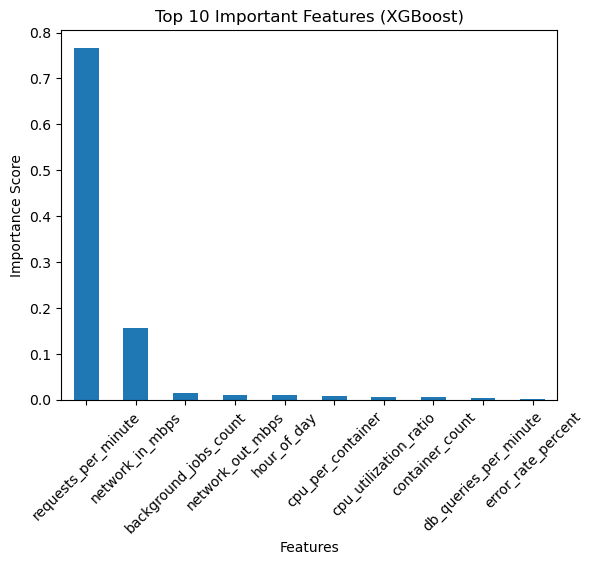

In [51]:
feature_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features (XGBoost)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

In [52]:
feature_df = feature_importance.reset_index()
feature_df.columns = ['Feature', 'Importance']

print(feature_df.head(10))

                 Feature  Importance
0    requests_per_minute    0.767087
1        network_in_mbps    0.155748
2  background_jobs_count    0.014059
3       network_out_mbps    0.010486
4            hour_of_day    0.009312
5      cpu_per_container    0.008979
6  cpu_utilization_ratio    0.005771
7        container_count    0.005277
8  db_queries_per_minute    0.002800
9     error_rate_percent    0.002137


The analysis shows that CPU utilization is primarily driven by request volume and incoming network traffic. These two features alone contribute to more than 90% of the predictive power of the model. Secondary factors such as background jobs and time-based patterns have a smaller but noticeable impact. Engineered features like CPU per container and utilization ratios further improve model understanding, indicating that resource efficiency plays a role in system performance. Overall, the system is highly request-driven, and optimizing request handling and traffic management would yield the most significant performance improvements.